Step 1 — Upload and inspect the new KRI files

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
df = pd.read_csv("https://raw.githubusercontent.com/robert-korir/Datasets/refs/heads/main/Merged_KRI_Daily.csv")
df

,date,KRI4_chargebacks,KRI5_refund_ops,KRI1,KRI2,KRI3_waiting_gt14
0,2026-01-06,NaN,2.0,NaN,NaN,NaN
1,2026-01-07,NaN,3.0,NaN,NaN,NaN
2,2026-01-08,NaN,3.0,NaN,NaN,NaN
3,2026-01-09,NaN,3.0,NaN,NaN,NaN
4,2026-01-10,NaN,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...
228,2026-08-22,203.0,454.0,642.0,688497.0,46.0
229,2026-08-23,205.0,454.0,638.0,688515.0,42.0
230,2026-08-24,207.0,454.0,687.0,688516.0,43.0
231,2026-08-25,208.0,454.0,692.0,688580.0,48.0


Step 1C — Inspect the Excel workbook containing KRI1, KRI2 and KRI3

In [5]:
# ============================================================
# STEP 1A: UPLOAD THE KRI DATA FILES
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nFiles uploaded:")
for filename in uploaded.keys():
    print("-", filename)

Saving Risk Indicator_5_Historical_20260826.csv to Risk Indicator_5_Historical_20260826.csv
Saving Risk_Indicator_1,2,3_20260826.xlsx to Risk_Indicator_1,2,3_20260826.xlsx
Saving Risk_Indicator_4_20260826.csv to Risk_Indicator_4_20260826.csv

Files uploaded:
- Risk Indicator_5_Historical_20260826.csv
- Risk_Indicator_1,2,3_20260826.xlsx
- Risk_Indicator_4_20260826.csv


In [6]:
# ============================================================
# STEP 1B: IDENTIFY THE FILES
# ============================================================

import pandas as pd
import numpy as np
import os

all_files = os.listdir("/content")

print("Files currently available in Colab:")
for f in all_files:
    print(f)

# Locate the required files automatically
kri123_file = next(
    f for f in all_files
    if "Risk_Indicator_1,2,3" in f
)

kri4_file = next(
    f for f in all_files
    if "Risk_Indicator_4_20260826" in f
)

kri5_file = next(
    f for f in all_files
    if "Historical_20260826" in f
)

print("\nSelected files:")
print("KRI 1,2,3:", kri123_file)
print("KRI 4:", kri4_file)
print("KRI 5 Historical:", kri5_file)

Files currently available in Colab:
.config
Risk_Indicator_4_20260826.csv
Merged_KRI_Daily.csv
Risk_Indicator_1,2,3_20260826.xlsx
Risk Indicator_5_Historical_20260826.csv
sample_data

Selected files:
KRI 1,2,3: Risk_Indicator_1,2,3_20260826.xlsx
KRI 4: Risk_Indicator_4_20260826.csv
KRI 5 Historical: Risk Indicator_5_Historical_20260826.csv


**Step 1D — Inspect updated KRI4**

In [7]:
# ============================================================
# STEP 1D: INSPECT UPDATED KRI 4
# ============================================================

kri4 = pd.read_csv(
    f"/content/{kri4_file}"
)

print("KRI 4 SHAPE:")
print(kri4.shape)

print("\nKRI 4 COLUMNS:")
print(kri4.columns.tolist())

print("\nFIRST 10 ROWS:")
display(kri4.head(10))

print("\nLAST 10 ROWS:")
display(kri4.tail(10))

print("\nDATA TYPES:")
print(kri4.dtypes)

print("\nMISSING VALUES:")
print(kri4.isna().sum())

print("\nDESCRIPTIVE STATISTICS:")
display(kri4.describe(include="all"))

KRI 4 SHAPE:
(148, 2)

KRI 4 COLUMNS:
['date', 'n_chargeback']

FIRST 10 ROWS:


,date,n_chargeback
0,2026-04-01,1137
1,2026-04-02,1173
2,2026-04-03,1178
3,2026-04-04,1188
4,2026-04-05,1189
5,2026-04-06,1189
6,2026-04-07,1189
7,2026-04-08,1203
8,2026-04-09,1208
9,2026-04-10,1212



LAST 10 ROWS:


,date,n_chargeback
138,2026-08-17,194
139,2026-08-18,196
140,2026-08-19,200
141,2026-08-20,201
142,2026-08-21,201
143,2026-08-22,203
144,2026-08-23,205
145,2026-08-24,207
146,2026-08-25,208
147,2026-08-26,209



DATA TYPES:
date            object
n_chargeback     int64
dtype: object

MISSING VALUES:
date            0
n_chargeback    0
dtype: int64

DESCRIPTIVE STATISTICS:


,date,n_chargeback
count,148,148.000000
unique,148,NaN
top,2026-04-01,NaN
freq,1,NaN
mean,NaN,1009.472973
std,NaN,725.447237
min,NaN,158.000000
25%,NaN,194.000000
50%,NaN,1218.000000
75%,NaN,1534.750000


**Step 1E — Inspect historical refund data / KRI5**

In [8]:
# ============================================================
# STEP 1E: INSPECT KRI 5 - HISTORICAL REFUND DATA
# ============================================================

kri5 = pd.read_csv(
    f"/content/{kri5_file}"
)

print("KRI 5 SHAPE:")
print(kri5.shape)

print("\nKRI 5 COLUMNS:")
print(kri5.columns.tolist())

print("\nFIRST 10 ROWS:")
display(kri5.head(10))

print("\nLAST 10 ROWS:")
display(kri5.tail(10))

print("\nDATA TYPES:")
print(kri5.dtypes)

print("\nMISSING VALUES:")
print(kri5.isna().sum())

print("\nDESCRIPTIVE STATISTICS:")
display(kri5.describe(include="all"))

KRI 5 SHAPE:
(233, 2)

KRI 5 COLUMNS:
['date', 'refund_ops']

FIRST 10 ROWS:


,date,refund_ops
0,2026-08-26,451
1,2026-08-25,454
2,2026-08-24,454
3,2026-08-23,454
4,2026-08-22,454
5,2026-08-21,454
6,2026-08-20,454
7,2026-08-19,454
8,2026-08-18,454
9,2026-08-17,454



LAST 10 ROWS:


,date,refund_ops
223,2026-01-15,5
224,2026-01-14,4
225,2026-01-13,4
226,2026-01-12,3
227,2026-01-11,3
228,2026-01-10,3
229,2026-01-09,3
230,2026-01-08,3
231,2026-01-07,3
232,2026-01-06,2



DATA TYPES:
date          object
refund_ops     int64
dtype: object

MISSING VALUES:
date          0
refund_ops    0
dtype: int64

DESCRIPTIVE STATISTICS:


,date,refund_ops
count,233,233.000000
unique,233,NaN
top,2026-08-26,NaN
freq,1,NaN
mean,NaN,218.145923
std,NaN,389.856622
min,NaN,2.000000
25%,NaN,9.000000
50%,NaN,16.000000
75%,NaN,282.000000


**Step 1F — Automatically identify likely date columns**

In [9]:
# ============================================================
# STEP 1F: CHECK POSSIBLE DATE COLUMNS
# ============================================================

def inspect_date_columns(df, dataset_name):

    print("\n" + "=" * 70)
    print(dataset_name)
    print("=" * 70)

    for col in df.columns:

        converted = pd.to_datetime(
            df[col],
            errors="coerce"
        )

        valid = converted.notna().sum()

        if valid > 0:

            print(
                f"{col}: "
                f"{valid}/{len(df)} values "
                f"convertible to dates"
            )

            if valid >= len(df) * 0.5:

                print(
                    "  Earliest:",
                    converted.min()
                )

                print(
                    "  Latest:",
                    converted.max()
                )


inspect_date_columns(
    kri4,
    "KRI 4 DATE CHECK"
)

inspect_date_columns(
    kri5,
    "KRI 5 DATE CHECK"
)


KRI 4 DATE CHECK
date: 148/148 values convertible to dates
  Earliest: 2026-04-01 00:00:00
  Latest: 2026-08-26 00:00:00
n_chargeback: 148/148 values convertible to dates
  Earliest: 1970-01-01 00:00:00.000000158
  Latest: 1970-01-01 00:00:00.000002191

KRI 5 DATE CHECK
date: 233/233 values convertible to dates
  Earliest: 2026-01-06 00:00:00
  Latest: 2026-08-26 00:00:00
refund_ops: 233/233 values convertible to dates
  Earliest: 1970-01-01 00:00:00.000000002
  Latest: 1970-01-01 00:00:00.000001611


**Step 2A — Clean KRI1, KRI2 and KRI3**

In [10]:
# ============================================================
# STEP 2A: CLEAN KRI 1, KRI 2 AND KRI 3
# ============================================================

import pandas as pd
import numpy as np

kri123_raw = pd.read_excel(
    "/content/Risk_Indicator_1,2,3_20260826.xlsx"
)

print("Original KRI1-3 rows:", len(kri123_raw))

# ------------------------------------------------------------
# Convert snapshot date
# Excel stores these dates as serial numbers
# ------------------------------------------------------------

if pd.api.types.is_numeric_dtype(kri123_raw["snapshot_date"]):

    kri123_raw["date"] = pd.to_datetime(
        kri123_raw["snapshot_date"],
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )

else:

    kri123_raw["date"] = pd.to_datetime(
        kri123_raw["snapshot_date"],
        errors="coerce"
    )


# ------------------------------------------------------------
# Convert KRI identifiers and values to numeric
# ------------------------------------------------------------

kri123_raw["Risk Indicator"] = pd.to_numeric(
    kri123_raw["Risk Indicator"],
    errors="coerce"
)

kri123_raw["SUM(indicator_value)"] = pd.to_numeric(
    kri123_raw["SUM(indicator_value)"],
    errors="coerce"
)


# ------------------------------------------------------------
# Remove unusable rows
# ------------------------------------------------------------

kri123_clean = (
    kri123_raw
    .dropna(
        subset=[
            "date",
            "Risk Indicator",
            "SUM(indicator_value)"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# Check duplicates
# ------------------------------------------------------------

duplicates_123 = kri123_clean.duplicated(
    subset=[
        "date",
        "Risk Indicator"
    ]
).sum()

print(
    "Duplicate date/KRI combinations:",
    duplicates_123
)


# ------------------------------------------------------------
# Pivot into one row per observation date
# ------------------------------------------------------------

kri123 = (
    kri123_clean
    .pivot_table(
        index="date",
        columns="Risk Indicator",
        values="SUM(indicator_value)",
        aggfunc="sum"
    )
    .reset_index()
)


# Rename KRI columns
kri123 = kri123.rename(
    columns={
        1: "KRI1",
        2: "KRI2",
        3: "KRI3_waiting_refunds_after_14_days"
    }
)


# Remove column-index name created by pivot
kri123.columns.name = None


# Sort chronologically
kri123 = (
    kri123
    .sort_values("date")
    .reset_index(drop=True)
)


print("\nCLEANED KRI 1-3 DATA")
display(kri123)

print("\nKRI 1-3 DATE RANGE")
print(
    kri123["date"].min(),
    "to",
    kri123["date"].max()
)

print("\nOBSERVATION COUNTS")
print(
    kri123[
        [
            "KRI1",
            "KRI2",
            "KRI3_waiting_refunds_after_14_days"
        ]
    ].count()
)

Original KRI1-3 rows: 33
Duplicate date/KRI combinations: 0

CLEANED KRI 1-3 DATA


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days
0,2026-07-27,1044,687953,19
1,2026-08-07,837,688093,9
2,2026-08-14,603,688216,38
3,2026-08-19,754,688383,40
4,2026-08-20,1038,688408,44
5,2026-08-21,1113,688477,47
6,2026-08-22,642,688497,46
7,2026-08-23,638,688515,42
8,2026-08-24,687,688516,43
9,2026-08-25,692,688580,48



KRI 1-3 DATE RANGE
2026-07-27 00:00:00 to 2026-08-26 00:00:00

OBSERVATION COUNTS
KRI1                                  11
KRI2                                  11
KRI3_waiting_refunds_after_14_days    11
dtype: int64


**Step 2B — Clean updated KRI4: Chargebacks**

In [11]:
# ============================================================
# STEP 2B: CLEAN KRI 4 - CHARGEBACKS
# ============================================================

kri4 = pd.read_csv(
    "/content/Risk_Indicator_4_20260826.csv"
)

print("Original KRI4 rows:", len(kri4))


# Date conversion
kri4["date"] = pd.to_datetime(
    kri4["date"],
    errors="coerce"
)


# Numeric conversion
kri4["n_chargeback"] = pd.to_numeric(
    kri4["n_chargeback"],
    errors="coerce"
)


# Remove unusable records
kri4 = (
    kri4
    .dropna(
        subset=[
            "date",
            "n_chargeback"
        ]
    )
    .copy()
)


# Check duplicate dates
duplicate_kri4 = kri4.duplicated(
    subset=["date"]
).sum()

print(
    "Duplicate KRI4 dates:",
    duplicate_kri4
)


# If duplicates exist, retain the most recent record
kri4 = (
    kri4
    .drop_duplicates(
        subset=["date"],
        keep="last"
    )
    .sort_values("date")
    .reset_index(drop=True)
)


# Rename for multi-KRI model
kri4 = kri4.rename(
    columns={
        "n_chargeback":
        "KRI4_chargebacks"
    }
)


print("\nCLEANED KRI4")
display(kri4.head())

print("\nKRI4 LAST OBSERVATIONS")
display(kri4.tail())

print("\nKRI4 DATE RANGE")
print(
    kri4["date"].min(),
    "to",
    kri4["date"].max()
)

print(
    "KRI4 observations:",
    len(kri4)
)

Original KRI4 rows: 148
Duplicate KRI4 dates: 0

CLEANED KRI4


,date,KRI4_chargebacks
0,2026-04-01,1137
1,2026-04-02,1173
2,2026-04-03,1178
3,2026-04-04,1188
4,2026-04-05,1189



KRI4 LAST OBSERVATIONS


,date,KRI4_chargebacks
143,2026-08-22,203
144,2026-08-23,205
145,2026-08-24,207
146,2026-08-25,208
147,2026-08-26,209



KRI4 DATE RANGE
2026-04-01 00:00:00 to 2026-08-26 00:00:00
KRI4 observations: 148


**Step 2C — Clean KRI5: Historical Refund Operations**

In [12]:
# ============================================================
# STEP 2C: CLEAN KRI 5 - HISTORICAL REFUND OPERATIONS
# ============================================================

kri5 = pd.read_csv(
    "/content/Risk Indicator_5_Historical_20260826.csv"
)

print("Original KRI5 rows:", len(kri5))


# Convert dates
kri5["date"] = pd.to_datetime(
    kri5["date"],
    errors="coerce"
)


# Convert values
kri5["refund_ops"] = pd.to_numeric(
    kri5["refund_ops"],
    errors="coerce"
)


# Remove unusable records
kri5 = (
    kri5
    .dropna(
        subset=[
            "date",
            "refund_ops"
        ]
    )
    .copy()
)


# Check duplicates
duplicate_kri5 = kri5.duplicated(
    subset=["date"]
).sum()

print(
    "Duplicate KRI5 dates:",
    duplicate_kri5
)


# Remove duplicate dates
kri5 = (
    kri5
    .drop_duplicates(
        subset=["date"],
        keep="last"
    )
    .sort_values("date")
    .reset_index(drop=True)
)


# Rename
kri5 = kri5.rename(
    columns={
        "refund_ops":
        "KRI5_historical_refund_operations"
    }
)


print("\nCLEANED KRI5")
display(kri5.head())

print("\nLAST KRI5 OBSERVATIONS")
display(kri5.tail())

print("\nKRI5 DATE RANGE")
print(
    kri5["date"].min(),
    "to",
    kri5["date"].max()
)

print(
    "KRI5 observations:",
    len(kri5)
)

Original KRI5 rows: 233
Duplicate KRI5 dates: 0

CLEANED KRI5


,date,KRI5_historical_refund_operations
0,2026-01-06,2
1,2026-01-07,3
2,2026-01-08,3
3,2026-01-09,3
4,2026-01-10,3



LAST KRI5 OBSERVATIONS


,date,KRI5_historical_refund_operations
228,2026-08-22,454
229,2026-08-23,454
230,2026-08-24,454
231,2026-08-25,454
232,2026-08-26,451



KRI5 DATE RANGE
2026-01-06 00:00:00 to 2026-08-26 00:00:00
KRI5 observations: 233


**Step 2E — Produce a clean KRI coverage table**

In [13]:
# ============================================================
# STEP 2E: KRI DATA COVERAGE SUMMARY
# ============================================================

coverage = pd.DataFrame([
    {
        "KRI": "KRI1",
        "Observations": kri123["KRI1"].count(),
        "Start Date":
            kri123.loc[
                kri123["KRI1"].notna(),
                "date"
            ].min(),
        "End Date":
            kri123.loc[
                kri123["KRI1"].notna(),
                "date"
            ].max()
    },

    {
        "KRI": "KRI2",
        "Observations": kri123["KRI2"].count(),
        "Start Date":
            kri123.loc[
                kri123["KRI2"].notna(),
                "date"
            ].min(),
        "End Date":
            kri123.loc[
                kri123["KRI2"].notna(),
                "date"
            ].max()
    },

    {
        "KRI": "Waiting Refunds After 14 Days",
        "Observations":
            kri123[
                "KRI3_waiting_refunds_after_14_days"
            ].count(),
        "Start Date":
            kri123.loc[
                kri123[
                    "KRI3_waiting_refunds_after_14_days"
                ].notna(),
                "date"
            ].min(),
        "End Date":
            kri123.loc[
                kri123[
                    "KRI3_waiting_refunds_after_14_days"
                ].notna(),
                "date"
            ].max()
    },

    {
        "KRI": "Daily Chargebacks",
        "Observations":
            kri4[
                "KRI4_chargebacks"
            ].count(),
        "Start Date":
            kri4["date"].min(),
        "End Date":
            kri4["date"].max()
    },

    {
        "KRI": "Historical Refund Operations",
        "Observations":
            kri5[
                "KRI5_historical_refund_operations"
            ].count(),
        "Start Date":
            kri5["date"].min(),
        "End Date":
            kri5["date"].max()
    }
])


print("\nTABLE: KRI DATA COVERAGE")
display(coverage)


TABLE: KRI DATA COVERAGE


,KRI,Observations,Start Date,End Date
0,KRI1,11,2026-07-27,2026-08-26
1,KRI2,11,2026-07-27,2026-08-26
2,Waiting Refunds After 14 Days,11,2026-07-27,2026-08-26
3,Daily Chargebacks,148,2026-04-01,2026-08-26
4,Historical Refund Operations,233,2026-01-06,2026-08-26


**Step 2F — Save the cleaned datasets**

In [14]:
# ============================================================
# STEP 2F: SAVE CLEAN DATA
# ============================================================

kri123.to_csv(
    "/content/Clean_KRI_1_2_3.csv",
    index=False
)

kri4.to_csv(
    "/content/Clean_KRI_4_Chargebacks.csv",
    index=False
)

kri5.to_csv(
    "/content/Clean_KRI_5_Historical_Refunds.csv",
    index=False
)

coverage.to_csv(
    "/content/KRI_Data_Coverage.csv",
    index=False
)

print("Clean datasets saved successfully.")

Clean datasets saved successfully.


**Step 3A — Load the cleaned datasets**

In [15]:
# ============================================================
# STEP 3A: LOAD CLEANED KRI DATASETS
# ============================================================

import pandas as pd
import numpy as np

kri123 = pd.read_csv(
    "/content/Clean_KRI_1_2_3.csv"
)

kri4 = pd.read_csv(
    "/content/Clean_KRI_4_Chargebacks.csv"
)

kri5 = pd.read_csv(
    "/content/Clean_KRI_5_Historical_Refunds.csv"
)

# Convert dates again after loading CSVs
for df_temp in [kri123, kri4, kri5]:
    df_temp["date"] = pd.to_datetime(
        df_temp["date"],
        errors="coerce"
    )

print("KRI1-3 rows:", len(kri123))
print("KRI4 rows:", len(kri4))
print("KRI5 rows:", len(kri5))

KRI1-3 rows: 11
KRI4 rows: 148
KRI5 rows: 233


**Step 3B — Merge all datasets using an outer join**

In [16]:
# ============================================================
# STEP 3B: MERGE ALL FIVE KRIs BY DATE
# ============================================================

master_kri = (
    kri4
    .merge(
        kri5,
        on="date",
        how="outer"
    )
    .merge(
        kri123,
        on="date",
        how="outer"
    )
)

master_kri = (
    master_kri
    .sort_values("date")
    .reset_index(drop=True)
)

print("MASTER DATASET SHAPE:")
print(master_kri.shape)

print("\nMASTER DATASET COLUMNS:")
print(master_kri.columns.tolist())

print("\nFIRST 15 ROWS:")
display(master_kri.head(15))

print("\nLAST 15 ROWS:")
display(master_kri.tail(15))

MASTER DATASET SHAPE:
(233, 6)

MASTER DATASET COLUMNS:
['date', 'KRI4_chargebacks', 'KRI5_historical_refund_operations', 'KRI1', 'KRI2', 'KRI3_waiting_refunds_after_14_days']

FIRST 15 ROWS:


,date,KRI4_chargebacks,KRI5_historical_refund_operations,KRI1,KRI2,KRI3_waiting_refunds_after_14_days
0,2026-01-06,NaN,2,NaN,NaN,NaN
1,2026-01-07,NaN,3,NaN,NaN,NaN
2,2026-01-08,NaN,3,NaN,NaN,NaN
3,2026-01-09,NaN,3,NaN,NaN,NaN
4,2026-01-10,NaN,3,NaN,NaN,NaN
5,2026-01-11,NaN,3,NaN,NaN,NaN
6,2026-01-12,NaN,3,NaN,NaN,NaN
7,2026-01-13,NaN,4,NaN,NaN,NaN
8,2026-01-14,NaN,4,NaN,NaN,NaN
9,2026-01-15,NaN,5,NaN,NaN,NaN



LAST 15 ROWS:


,date,KRI4_chargebacks,KRI5_historical_refund_operations,KRI1,KRI2,KRI3_waiting_refunds_after_14_days
218,2026-08-12,190.0,456,NaN,NaN,NaN
219,2026-08-13,193.0,456,NaN,NaN,NaN
220,2026-08-14,193.0,456,603.0,688216.0,38.0
221,2026-08-15,193.0,456,NaN,NaN,NaN
222,2026-08-16,194.0,454,NaN,NaN,NaN
223,2026-08-17,194.0,454,NaN,NaN,NaN
224,2026-08-18,196.0,454,NaN,NaN,NaN
225,2026-08-19,200.0,454,754.0,688383.0,40.0
226,2026-08-20,201.0,454,1038.0,688408.0,44.0
227,2026-08-21,201.0,454,1113.0,688477.0,47.0


**Step 3C — Reorder the columns**

In [17]:
# ============================================================
# STEP 3C: STANDARDIZE COLUMN ORDER
# ============================================================

desired_columns = [
    "date",
    "KRI1",
    "KRI2",
    "KRI3_waiting_refunds_after_14_days",
    "KRI4_chargebacks",
    "KRI5_historical_refund_operations"
]

master_kri = master_kri[
    desired_columns
]

display(master_kri.head())

,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations
0,2026-01-06,NaN,NaN,NaN,NaN,2
1,2026-01-07,NaN,NaN,NaN,NaN,3
2,2026-01-08,NaN,NaN,NaN,NaN,3
3,2026-01-09,NaN,NaN,NaN,NaN,3
4,2026-01-10,NaN,NaN,NaN,NaN,3


**Step 3D — Check data availability across the merged dataset**

In [18]:
# ============================================================
# STEP 3D: MASTER DATA AVAILABILITY
# ============================================================

availability = pd.DataFrame({
    "KRI": [
        "KRI1",
        "KRI2",
        "Waiting Refunds After 14 Days",
        "Daily Chargebacks",
        "Historical Refund Operations"
    ],

    "Available Observations": [
        master_kri["KRI1"].notna().sum(),
        master_kri["KRI2"].notna().sum(),
        master_kri[
            "KRI3_waiting_refunds_after_14_days"
        ].notna().sum(),
        master_kri[
            "KRI4_chargebacks"
        ].notna().sum(),
        master_kri[
            "KRI5_historical_refund_operations"
        ].notna().sum()
    ],

    "Missing Observations": [
        master_kri["KRI1"].isna().sum(),
        master_kri["KRI2"].isna().sum(),
        master_kri[
            "KRI3_waiting_refunds_after_14_days"
        ].isna().sum(),
        master_kri[
            "KRI4_chargebacks"
        ].isna().sum(),
        master_kri[
            "KRI5_historical_refund_operations"
        ].isna().sum()
    ]
})

availability["Coverage (%)"] = (
    availability["Available Observations"]
    / len(master_kri)
    * 100
).round(2)

print("\nKRI AVAILABILITY IN MASTER DATASET")
display(availability)


KRI AVAILABILITY IN MASTER DATASET


,KRI,Available Observations,Missing Observations,Coverage (%)
0,KRI1,11,222,4.72
1,KRI2,11,222,4.72
2,Waiting Refunds After 14 Days,11,222,4.72
3,Daily Chargebacks,148,85,63.52
4,Historical Refund Operations,233,0,100.00


**Step 3E — Identify dates where all five KRIs are available**

In [19]:
# ============================================================
# STEP 3E: FIND COMPLETE FIVE-KRI OBSERVATIONS
# ============================================================

kri_columns = [
    "KRI1",
    "KRI2",
    "KRI3_waiting_refunds_after_14_days",
    "KRI4_chargebacks",
    "KRI5_historical_refund_operations"
]

master_kri["Available_KRI_Count"] = (
    master_kri[kri_columns]
    .notna()
    .sum(axis=1)
)

complete_five_kri = master_kri[
    master_kri["Available_KRI_Count"] == 5
].copy()

print(
    "Dates with all five KRIs available:",
    len(complete_five_kri)
)

display(
    complete_five_kri[
        ["date"] + kri_columns
    ]
)

Dates with all five KRIs available: 11


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations
202,2026-07-27,1044.0,687953.0,19.0,176.0,1459
213,2026-08-07,837.0,688093.0,9.0,189.0,1531
220,2026-08-14,603.0,688216.0,38.0,193.0,456
225,2026-08-19,754.0,688383.0,40.0,200.0,454
226,2026-08-20,1038.0,688408.0,44.0,201.0,454
227,2026-08-21,1113.0,688477.0,47.0,201.0,454
228,2026-08-22,642.0,688497.0,46.0,203.0,454
229,2026-08-23,638.0,688515.0,42.0,205.0,454
230,2026-08-24,687.0,688516.0,43.0,207.0,454
231,2026-08-25,692.0,688580.0,48.0,208.0,454


**Step 3F — Check the overlap between daily KRI4 and KRI5**

In [20]:
# ============================================================
# STEP 3F: DAILY OVERLAP BETWEEN KRI4 AND KRI5
# ============================================================

daily_overlap = master_kri[
    master_kri[
        [
            "KRI4_chargebacks",
            "KRI5_historical_refund_operations"
        ]
    ].notna().all(axis=1)
].copy()

print(
    "Dates with both KRI4 and KRI5:",
    len(daily_overlap)
)

print(
    "Overlap date range:",
    daily_overlap["date"].min(),
    "to",
    daily_overlap["date"].max()
)

display(
    daily_overlap[
        [
            "date",
            "KRI4_chargebacks",
            "KRI5_historical_refund_operations"
        ]
    ].head(10)
)

Dates with both KRI4 and KRI5: 148
Overlap date range: 2026-04-01 00:00:00 to 2026-08-26 00:00:00


,date,KRI4_chargebacks,KRI5_historical_refund_operations
85,2026-04-01,1137.0,9
86,2026-04-02,1173.0,10
87,2026-04-03,1178.0,10
88,2026-04-04,1188.0,9
89,2026-04-05,1189.0,9
90,2026-04-06,1189.0,9
91,2026-04-07,1189.0,9
92,2026-04-08,1203.0,9
93,2026-04-09,1208.0,9
94,2026-04-10,1212.0,9


**Step 3G — Create a data-coverage matrix**

In [21]:
# ============================================================
# STEP 3G: DATA COVERAGE MATRIX
# ============================================================

coverage_matrix = master_kri[
    ["date"] + kri_columns
].copy()

for col in kri_columns:
    coverage_matrix[col] = (
        coverage_matrix[col]
        .notna()
        .astype(int)
    )

print("\nDATA COVERAGE MATRIX")
display(coverage_matrix.head(20))


DATA COVERAGE MATRIX


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations
0,2026-01-06,0,0,0,0,1
1,2026-01-07,0,0,0,0,1
2,2026-01-08,0,0,0,0,1
3,2026-01-09,0,0,0,0,1
4,2026-01-10,0,0,0,0,1
5,2026-01-11,0,0,0,0,1
6,2026-01-12,0,0,0,0,1
7,2026-01-13,0,0,0,0,1
8,2026-01-14,0,0,0,0,1
9,2026-01-15,0,0,0,0,1


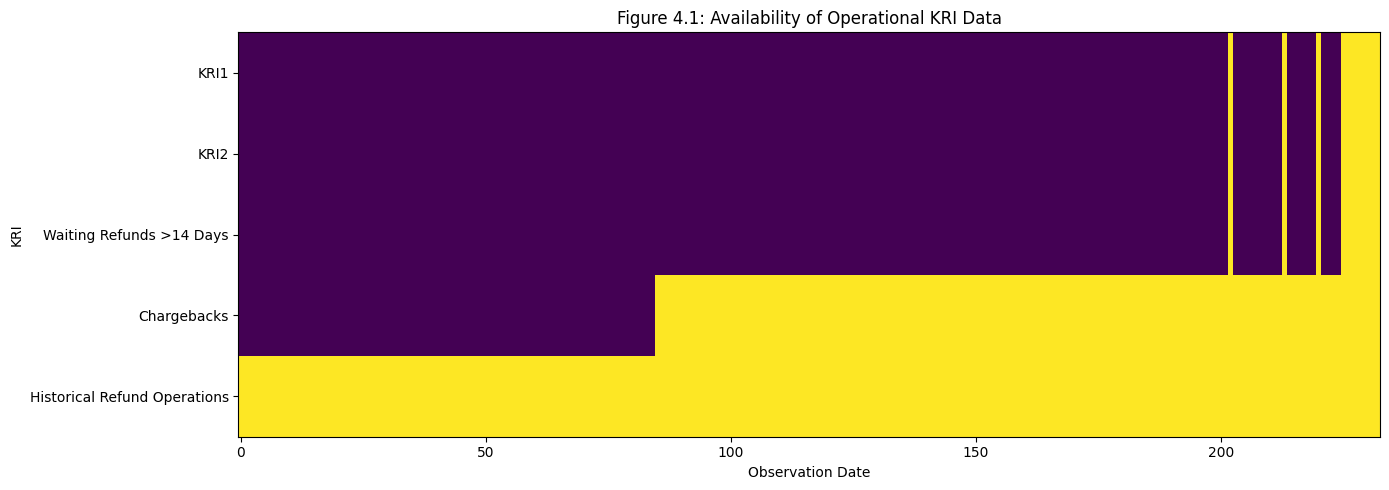

In [22]:
# ============================================================
# FIGURE: KRI DATA AVAILABILITY BY DATE
# ============================================================

import matplotlib.pyplot as plt

plot_data = (
    coverage_matrix
    .set_index("date")
    .T
)

plt.figure(figsize=(14, 5))

plt.imshow(
    plot_data,
    aspect="auto",
    interpolation="nearest"
)

plt.yticks(
    range(len(plot_data.index)),
    [
        "KRI1",
        "KRI2",
        "Waiting Refunds >14 Days",
        "Chargebacks",
        "Historical Refund Operations"
    ]
)

plt.xlabel("Observation Date")
plt.ylabel("KRI")

plt.title(
    "Figure 4.1: Availability of Operational KRI Data"
)

plt.tight_layout()

plt.savefig(
    "/content/Figure_4_1_KRI_Data_Availability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 3H — Save the master dataset**

In [23]:
# ============================================================
# STEP 3H: SAVE MASTER DATASET
# ============================================================

master_kri.to_csv(
    "/content/Master_Multi_KRI_Dataset.csv",
    index=False
)

complete_five_kri.to_csv(
    "/content/Complete_Five_KRI_Observations.csv",
    index=False
)

daily_overlap.to_csv(
    "/content/KRI4_KRI5_Daily_Overlap.csv",
    index=False
)

availability.to_csv(
    "/content/Master_KRI_Availability.csv",
    index=False
)

print("Master datasets saved successfully.")

Master datasets saved successfully.


**Step 4A — Load the master dataset**

In [24]:
# ============================================================
# STEP 4A: LOAD MASTER MULTI-KRI DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_kri = pd.read_csv(
    "/content/Master_Multi_KRI_Dataset.csv"
)

master_kri["date"] = pd.to_datetime(
    master_kri["date"],
    errors="coerce"
)

master_kri = (
    master_kri
    .sort_values("date")
    .reset_index(drop=True)
)

print("Master dataset shape:", master_kri.shape)

display(master_kri.head())

Master dataset shape: (233, 7)


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations,Available_KRI_Count
0,2026-01-06,NaN,NaN,NaN,NaN,2,1
1,2026-01-07,NaN,NaN,NaN,NaN,3,1
2,2026-01-08,NaN,NaN,NaN,NaN,3,1
3,2026-01-09,NaN,NaN,NaN,NaN,3,1
4,2026-01-10,NaN,NaN,NaN,NaN,3,1


**Step 4B — Descriptive statistics for all five KRIs**

In [25]:
# ============================================================
# STEP 4B: DESCRIPTIVE STATISTICS FOR ALL FIVE KRIs
# ============================================================

kri_info = {
    "KRI1": "KRI1",
    "KRI2": "KRI2",
    "Waiting Refunds After 14 Days":
        "KRI3_waiting_refunds_after_14_days",
    "Daily Chargebacks":
        "KRI4_chargebacks",
    "Historical Refund Operations":
        "KRI5_historical_refund_operations"
}


def kri_descriptive_stats(df, name, column):

    data = df[
        ["date", column]
    ].dropna().copy()

    n = len(data)

    mean = data[column].mean()
    median = data[column].median()
    std = data[column].std()

    minimum = data[column].min()
    maximum = data[column].max()

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    if mean != 0:
        cv = (std / mean) * 100
    else:
        cv = np.nan

    skewness = data[column].skew()

    return {
        "KRI": name,
        "Observations": n,
        "Start Date": data["date"].min(),
        "End Date": data["date"].max(),
        "Mean": mean,
        "Median": median,
        "Std Dev": std,
        "Minimum": minimum,
        "Q1": q1,
        "Q3": q3,
        "Maximum": maximum,
        "IQR": iqr,
        "CV (%)": cv,
        "Skewness": skewness
    }


summary_rows = []

for name, column in kri_info.items():

    summary_rows.append(
        kri_descriptive_stats(
            master_kri,
            name,
            column
        )
    )


table_4_2 = pd.DataFrame(
    summary_rows
)

numeric_cols = [
    "Mean",
    "Median",
    "Std Dev",
    "Minimum",
    "Q1",
    "Q3",
    "Maximum",
    "IQR",
    "CV (%)",
    "Skewness"
]

table_4_2[
    numeric_cols
] = table_4_2[
    numeric_cols
].round(2)


print(
    "\nTABLE 4.2: DESCRIPTIVE PROFILE "
    "OF THE MULTI-KRI DATASET"
)

display(table_4_2)


TABLE 4.2: DESCRIPTIVE PROFILE OF THE MULTI-KRI DATASET


,KRI,Observations,Start Date,End Date,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum,IQR,CV (%),Skewness
0,KRI1,11,2026-07-27,2026-08-26,786.18,692.0,192.35,600.0,640.0,937.50,1113.0,297.50,24.47,0.81
1,KRI2,11,2026-07-27,2026-08-26,688395.91,688477.0,224.27,687953.0,688299.5,688515.50,688717.0,216.00,0.03,-0.83
2,Waiting Refunds After 14 Days,11,2026-07-27,2026-08-26,37.18,42.0,12.43,9.0,35.5,45.00,48.0,9.50,33.44,-1.58
3,Daily Chargebacks,148,2026-04-01,2026-08-26,1009.47,1218.0,725.45,158.0,194.0,1534.75,2191.0,1340.75,71.86,0.07
4,Historical Refund Operations,233,2026-01-06,2026-08-26,218.15,16.0,389.86,2.0,9.0,282.00,1611.0,273.00,178.71,2.52


**Save it**

In [26]:
table_4_2.to_csv(
    "/content/Table_4_2_Multi_KRI_Descriptive_Statistics.csv",
    index=False
)

**Step 4C — Analyze Waiting Refunds After 14 Days**

In [27]:
# ============================================================
# STEP 4C: KRI3 - WAITING REFUNDS AFTER 14 DAYS
# ============================================================

kri3 = master_kri[
    [
        "date",
        "KRI3_waiting_refunds_after_14_days"
    ]
].dropna().copy()

print(
    "WAITING REFUNDS AFTER 14 DAYS"
)

print(
    "Observations:",
    len(kri3)
)

print(
    "Date range:",
    kri3["date"].min(),
    "to",
    kri3["date"].max()
)

print(
    "Mean:",
    round(
        kri3[
            "KRI3_waiting_refunds_after_14_days"
        ].mean(),
        2
    )
)

print(
    "Median:",
    round(
        kri3[
            "KRI3_waiting_refunds_after_14_days"
        ].median(),
        2
    )
)

print(
    "Minimum:",
    kri3[
        "KRI3_waiting_refunds_after_14_days"
    ].min()
)

print(
    "Maximum:",
    kri3[
        "KRI3_waiting_refunds_after_14_days"
    ].max()
)

display(kri3)

WAITING REFUNDS AFTER 14 DAYS
Observations: 11
Date range: 2026-07-27 00:00:00 to 2026-08-26 00:00:00
Mean: 37.18
Median: 42.0
Minimum: 9.0
Maximum: 48.0


,date,KRI3_waiting_refunds_after_14_days
202,2026-07-27,19.0
213,2026-08-07,9.0
220,2026-08-14,38.0
225,2026-08-19,40.0
226,2026-08-20,44.0
227,2026-08-21,47.0
228,2026-08-22,46.0
229,2026-08-23,42.0
230,2026-08-24,43.0
231,2026-08-25,48.0


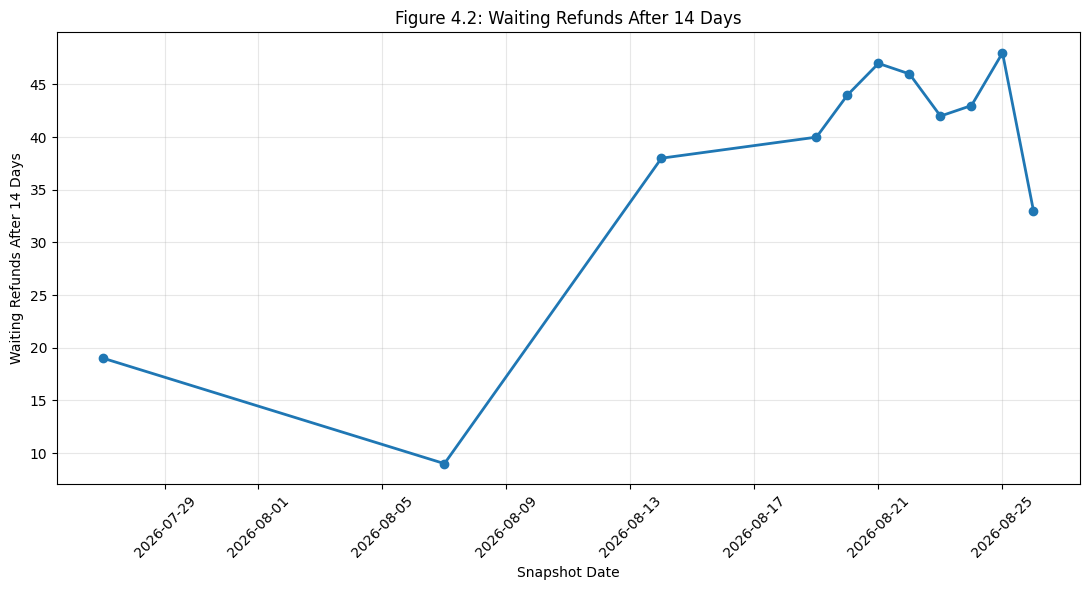

In [28]:
# ============================================================
# FIGURE 4.2:
# WAITING REFUNDS AFTER 14 DAYS
# ============================================================

plt.figure(
    figsize=(11, 6)
)

plt.plot(
    kri3["date"],
    kri3[
        "KRI3_waiting_refunds_after_14_days"
    ],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Snapshot Date"
)

plt.ylabel(
    "Waiting Refunds After 14 Days"
)

plt.title(
    "Figure 4.2: Waiting Refunds After 14 Days"
)

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Figure_4_2_Waiting_Refunds_After_14_Days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 4D — Analyze updated Daily Chargebacks**

In [29]:
# ============================================================
# STEP 4D: UPDATED DAILY CHARGEBACK KRI
# ============================================================

kri4_series = master_kri[
    [
        "date",
        "KRI4_chargebacks"
    ]
].dropna().copy()

kri4_series = (
    kri4_series
    .sort_values("date")
    .reset_index(drop=True)
)

# 7-day moving average
kri4_series[
    "Moving_Average_7"
] = (
    kri4_series[
        "KRI4_chargebacks"
    ]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)


print(
    "\nUPDATED CHARGEBACK KRI SUMMARY"
)

print(
    "Observations:",
    len(kri4_series)
)

print(
    "Start:",
    kri4_series["date"].min()
)

print(
    "End:",
    kri4_series["date"].max()
)

print(
    "Mean:",
    round(
        kri4_series[
            "KRI4_chargebacks"
        ].mean(),
        2
    )
)

print(
    "Median:",
    round(
        kri4_series[
            "KRI4_chargebacks"
        ].median(),
        2
    )
)

print(
    "Minimum:",
    kri4_series[
        "KRI4_chargebacks"
    ].min()
)

print(
    "Maximum:",
    kri4_series[
        "KRI4_chargebacks"
    ].max()
)


UPDATED CHARGEBACK KRI SUMMARY
Observations: 148
Start: 2026-04-01 00:00:00
End: 2026-08-26 00:00:00
Mean: 1009.47
Median: 1218.0
Minimum: 158.0
Maximum: 2191.0


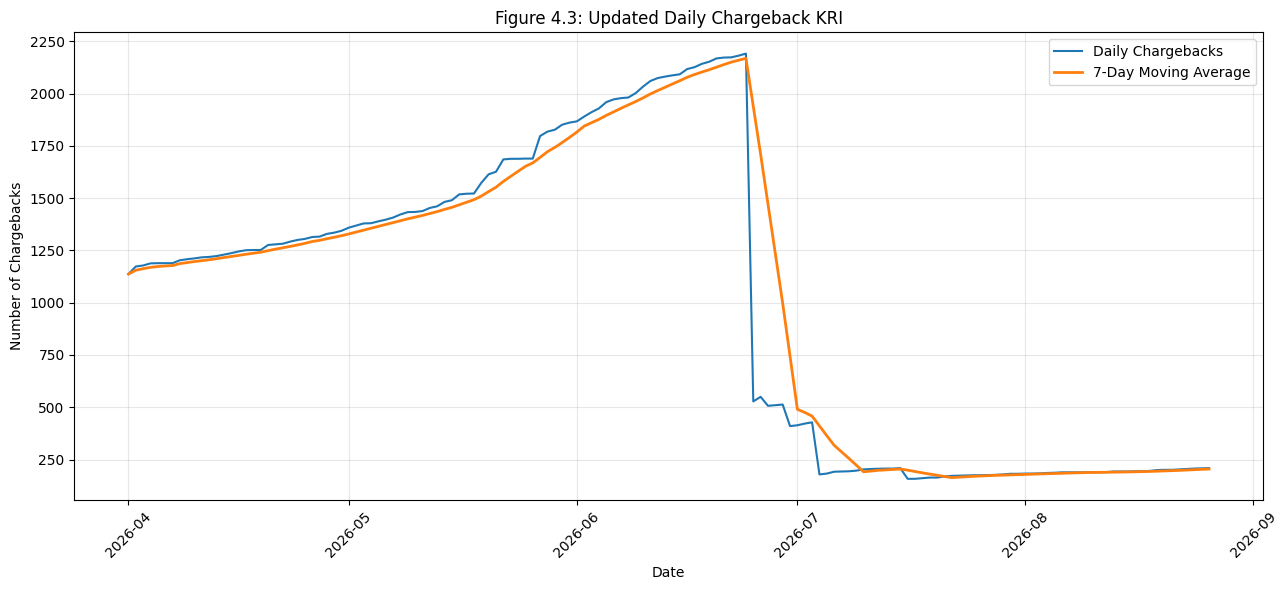

In [30]:
# ============================================================
# FIGURE 4.3:
# UPDATED DAILY CHARGEBACK KRI
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    kri4_series["date"],
    kri4_series["KRI4_chargebacks"],
    linewidth=1.5,
    label="Daily Chargebacks"
)

plt.plot(
    kri4_series["date"],
    kri4_series["Moving_Average_7"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.xlabel("Date")

plt.ylabel(
    "Number of Chargebacks"
)

plt.title(
    "Figure 4.3: Updated Daily Chargeback KRI"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Figure_4_3_Updated_Chargeback_KRI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 4E — Analyze Historical Refund Operations**

In [31]:
# ============================================================
# STEP 4E: HISTORICAL REFUND OPERATIONS
# ============================================================

kri5_series = master_kri[
    [
        "date",
        "KRI5_historical_refund_operations"
    ]
].dropna().copy()

kri5_series = (
    kri5_series
    .sort_values("date")
    .reset_index(drop=True)
)

kri5_series[
    "Moving_Average_7"
] = (
    kri5_series[
        "KRI5_historical_refund_operations"
    ]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)


print(
    "\nHISTORICAL REFUND OPERATIONS SUMMARY"
)

print(
    "Observations:",
    len(kri5_series)
)

print(
    "Start:",
    kri5_series["date"].min()
)

print(
    "End:",
    kri5_series["date"].max()
)

print(
    "Mean:",
    round(
        kri5_series[
            "KRI5_historical_refund_operations"
        ].mean(),
        2
    )
)

print(
    "Median:",
    round(
        kri5_series[
            "KRI5_historical_refund_operations"
        ].median(),
        2
    )
)

print(
    "Minimum:",
    kri5_series[
        "KRI5_historical_refund_operations"
    ].min()
)

print(
    "Maximum:",
    kri5_series[
        "KRI5_historical_refund_operations"
    ].max()
)


HISTORICAL REFUND OPERATIONS SUMMARY
Observations: 233
Start: 2026-01-06 00:00:00
End: 2026-08-26 00:00:00
Mean: 218.15
Median: 16.0
Minimum: 2
Maximum: 1611


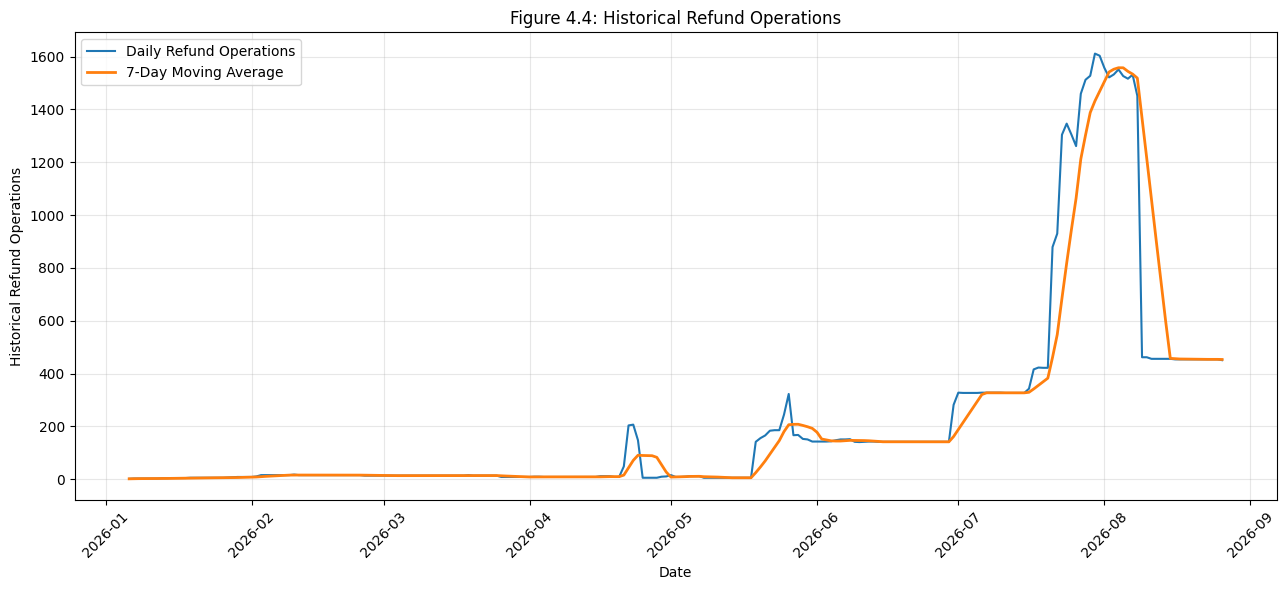

In [32]:
# ============================================================
# FIGURE 4.4:
# HISTORICAL REFUND OPERATIONS
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    kri5_series["date"],
    kri5_series[
        "KRI5_historical_refund_operations"
    ],
    linewidth=1.5,
    label="Daily Refund Operations"
)

plt.plot(
    kri5_series["date"],
    kri5_series[
        "Moving_Average_7"
    ],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.xlabel("Date")

plt.ylabel(
    "Historical Refund Operations"
)

plt.title(
    "Figure 4.4: Historical Refund Operations"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Figure_4_4_Historical_Refund_Operations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 4F — Monthly analysis of KRI4 and KRI5**

In [33]:
# ============================================================
# STEP 4F: MONTHLY SUMMARY FOR DAILY KRIs
# ============================================================

daily_pair = master_kri[
    [
        "date",
        "KRI4_chargebacks",
        "KRI5_historical_refund_operations"
    ]
].copy()

daily_pair["Month"] = (
    daily_pair["date"]
    .dt.to_period("M")
    .astype(str)
)


monthly_summary = (
    daily_pair
    .groupby("Month")
    .agg(
        KRI4_Observations=(
            "KRI4_chargebacks",
            "count"
        ),

        Mean_Chargebacks=(
            "KRI4_chargebacks",
            "mean"
        ),

        Median_Chargebacks=(
            "KRI4_chargebacks",
            "median"
        ),

        KRI5_Observations=(
            "KRI5_historical_refund_operations",
            "count"
        ),

        Mean_Refund_Operations=(
            "KRI5_historical_refund_operations",
            "mean"
        ),

        Median_Refund_Operations=(
            "KRI5_historical_refund_operations",
            "median"
        )
    )
    .reset_index()
)


monthly_summary[
    [
        "Mean_Chargebacks",
        "Median_Chargebacks",
        "Mean_Refund_Operations",
        "Median_Refund_Operations"
    ]
] = monthly_summary[
    [
        "Mean_Chargebacks",
        "Median_Chargebacks",
        "Mean_Refund_Operations",
        "Median_Refund_Operations"
    ]
].round(2)


print(
    "\nMONTHLY SUMMARY OF DAILY KRIs"
)

display(monthly_summary)


MONTHLY SUMMARY OF DAILY KRIs


,Month,KRI4_Observations,Mean_Chargebacks,Median_Chargebacks,KRI5_Observations,Mean_Refund_Operations,Median_Refund_Operations
0,2026-01,0,NaN,NaN,26,5.31,5.5
1,2026-02,0,NaN,NaN,28,15.36,16.0
2,2026-03,0,NaN,NaN,31,13.10,14.0
3,2026-04,30,1245.47,1241.0,30,28.13,9.0
4,2026-05,31,1556.77,1518.0,31,81.16,12.0
5,2026-06,30,1745.20,2017.5,30,148.00,142.0
6,2026-07,31,205.74,182.0,31,699.16,343.0
7,2026-08,26,194.00,193.0,26,783.85,456.0


**Save it**

In [34]:
monthly_summary.to_csv(
    "/content/"
    "Table_4_3_Monthly_Daily_KRI_Summary.csv",
    index=False
)

**Step 4G — Examine the relationship between chargebacks and refund operations**

In [35]:
# ============================================================
# STEP 4G: KRI4 - KRI5 RELATIONSHIP
# ============================================================

relationship_data = master_kri[
    [
        "date",
        "KRI4_chargebacks",
        "KRI5_historical_refund_operations"
    ]
].dropna().copy()


pearson_corr = (
    relationship_data[
        [
            "KRI4_chargebacks",
            "KRI5_historical_refund_operations"
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)


spearman_corr = (
    relationship_data[
        [
            "KRI4_chargebacks",
            "KRI5_historical_refund_operations"
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)


print(
    "Overlapping observations:",
    len(relationship_data)
)

print(
    "Pearson correlation:",
    round(pearson_corr, 4)
)

print(
    "Spearman correlation:",
    round(spearman_corr, 4)
)

Overlapping observations: 148
Pearson correlation: -0.6149
Spearman correlation: -0.6467


**Step 4H — Produce a concise interpretation-support table**

In [36]:
# ============================================================
# STEP 4H: INTERPRETATION SUPPORT
# ============================================================

interpretation_table = table_4_2[
    [
        "KRI",
        "Observations",
        "Mean",
        "Median",
        "Std Dev",
        "Minimum",
        "Maximum",
        "CV (%)",
        "Skewness"
    ]
].copy()


def variability_label(cv):

    if pd.isna(cv):
        return "Not determined"

    elif cv < 15:
        return "Low"

    elif cv < 35:
        return "Moderate"

    else:
        return "High"


interpretation_table[
    "Variability Description"
] = (
    interpretation_table[
        "CV (%)"
    ]
    .apply(variability_label)
)


def skew_label(value):

    if pd.isna(value):
        return "Not determined"

    elif value < -0.5:
        return "Negatively skewed"

    elif value > 0.5:
        return "Positively skewed"

    else:
        return "Approximately symmetric"


interpretation_table[
    "Distribution Description"
] = (
    interpretation_table[
        "Skewness"
    ]
    .apply(skew_label)
)


print(
    "\nMULTI-KRI INTERPRETATION SUPPORT"
)

display(
    interpretation_table
)


MULTI-KRI INTERPRETATION SUPPORT


,KRI,Observations,Mean,Median,Std Dev,Minimum,Maximum,CV (%),Skewness,Variability Description,Distribution Description
0,KRI1,11,786.18,692.0,192.35,600.0,1113.0,24.47,0.81,Moderate,Positively skewed
1,KRI2,11,688395.91,688477.0,224.27,687953.0,688717.0,0.03,-0.83,Low,Negatively skewed
2,Waiting Refunds After 14 Days,11,37.18,42.0,12.43,9.0,48.0,33.44,-1.58,Moderate,Negatively skewed
3,Daily Chargebacks,148,1009.47,1218.0,725.45,158.0,2191.0,71.86,0.07,High,Approximately symmetric
4,Historical Refund Operations,233,218.15,16.0,389.86,2.0,1611.0,178.71,2.52,High,Positively skewed


**Step 5A — Calculate Q1 and Q3 for every KRI**

In [37]:
# ============================================================
# STEP 5A: EMPIRICAL THRESHOLDS FOR ALL FIVE KRIs
# ============================================================

import pandas as pd
import numpy as np

# Reload master data if necessary
master_kri = pd.read_csv(
    "/content/Master_Multi_KRI_Dataset.csv"
)

master_kri["date"] = pd.to_datetime(
    master_kri["date"],
    errors="coerce"
)

kri_columns = {
    "KRI1": "KRI1",
    "KRI2": "KRI2",
    "Waiting Refunds After 14 Days":
        "KRI3_waiting_refunds_after_14_days",
    "Daily Chargebacks":
        "KRI4_chargebacks",
    "Historical Refund Operations":
        "KRI5_historical_refund_operations"
}


threshold_rows = []

for kri_name, column in kri_columns.items():

    values = (
        master_kri[column]
        .dropna()
        .astype(float)
    )

    q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    q3 = values.quantile(0.75)

    threshold_rows.append({
        "KRI": kri_name,
        "Observations": len(values),
        "Q1": q1,
        "Median": median,
        "Q3": q3,
        "Minimum": values.min(),
        "Maximum": values.max()
    })


candidate_thresholds = pd.DataFrame(
    threshold_rows
)

numeric_cols = [
    "Q1",
    "Median",
    "Q3",
    "Minimum",
    "Maximum"
]

candidate_thresholds[numeric_cols] = (
    candidate_thresholds[numeric_cols]
    .round(2)
)

print(
    "TABLE 4.X: CANDIDATE EMPIRICAL KRI THRESHOLDS"
)

display(candidate_thresholds)

TABLE 4.X: CANDIDATE EMPIRICAL KRI THRESHOLDS


,KRI,Observations,Q1,Median,Q3,Minimum,Maximum
0,KRI1,11,640.0,692.0,937.50,600.0,1113.0
1,KRI2,11,688299.5,688477.0,688515.50,687953.0,688717.0
2,Waiting Refunds After 14 Days,11,35.5,42.0,45.00,9.0,48.0
3,Daily Chargebacks,148,194.0,1218.0,1534.75,158.0,2191.0
4,Historical Refund Operations,233,9.0,16.0,282.00,2.0,1611.0


**Step 5B — Define the direction of risk**

In [38]:
# ============================================================
# STEP 5B: DEFINE KRI RISK DIRECTION
# ============================================================

risk_direction = {

    # Business definition still required
    "KRI1": "pending",

    # Business definition still required
    "KRI2": "pending",

    # More refunds waiting >14 days = worse
    "Waiting Refunds After 14 Days":
        "higher_is_worse",

    # More chargebacks = greater observed exposure
    "Daily Chargebacks":
        "higher_is_worse",

    # Keep as context-only until its exact
    # risk interpretation is confirmed
    "Historical Refund Operations":
        "context_only"
}


direction_table = pd.DataFrame({
    "KRI": risk_direction.keys(),
    "Risk Direction": risk_direction.values()
})

display(direction_table)

,KRI,Risk Direction
0,KRI1,pending
1,KRI2,pending
2,Waiting Refunds After 14 Days,higher_is_worse
3,Daily Chargebacks,higher_is_worse
4,Historical Refund Operations,context_only


**Step 5C — Generate operational thresholds for known adverse KRIs**

In [39]:
# ============================================================
# STEP 5C: CREATE OPERATIONAL THRESHOLDS
# ============================================================

threshold_config = {}

for kri_name, column in kri_columns.items():

    values = (
        master_kri[column]
        .dropna()
        .astype(float)
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    direction = risk_direction[kri_name]

    if direction == "higher_is_worse":

        threshold_config[kri_name] = {
            "direction": direction,
            "green_upper": q1,
            "red_lower": q3
        }

    elif direction == "lower_is_worse":

        threshold_config[kri_name] = {
            "direction": direction,
            "red_upper": q1,
            "green_lower": q3
        }

    else:

        threshold_config[kri_name] = {
            "direction": direction,
            "q1": q1,
            "q3": q3
        }


print("THRESHOLD CONFIGURATION")
print("=" * 70)

for kri, config in threshold_config.items():

    print(f"\n{kri}")

    for key, value in config.items():

        if isinstance(value, (int, float, np.number)):
            print(
                f"{key}: {value:,.2f}"
            )
        else:
            print(
                f"{key}: {value}"
            )

THRESHOLD CONFIGURATION

KRI1
direction: pending
q1: 640.00
q3: 937.50

KRI2
direction: pending
q1: 688,299.50
q3: 688,515.50

Waiting Refunds After 14 Days
direction: higher_is_worse
green_upper: 35.50
red_lower: 45.00

Daily Chargebacks
direction: higher_is_worse
green_upper: 194.00
red_lower: 1,534.75

Historical Refund Operations
direction: context_only
q1: 9.00
q3: 282.00


**Step 5D — Convert empirical boundaries to practical whole-number thresholds**

In [40]:
# ============================================================
# STEP 5D: PRACTICAL COUNT THRESHOLDS
# ============================================================

known_high_risk_kri = {
    "Waiting Refunds After 14 Days":
        "KRI3_waiting_refunds_after_14_days",

    "Daily Chargebacks":
        "KRI4_chargebacks"
}


operational_threshold_rows = []

for kri_name, column in known_high_risk_kri.items():

    values = (
        master_kri[column]
        .dropna()
        .astype(float)
    )

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    green_max = int(np.floor(q1))

    amber_min = green_max + 1

    amber_max = int(np.floor(q3))

    red_min = amber_max + 1

    operational_threshold_rows.append({

        "KRI": kri_name,

        "Q1": round(q1, 2),

        "Q3": round(q3, 2),

        "Green Range":
            f"<= {green_max:,}",

        "Amber Range":
            f"{amber_min:,} - {amber_max:,}",

        "Red Range":
            f">= {red_min:,}"
    })


operational_thresholds = pd.DataFrame(
    operational_threshold_rows
)

print(
    "\nOPERATIONAL GREEN-AMBER-RED THRESHOLDS"
)

display(
    operational_thresholds
)


OPERATIONAL GREEN-AMBER-RED THRESHOLDS


,KRI,Q1,Q3,Green Range,Amber Range,Red Range
0,Waiting Refunds After 14 Days,35.5,45.00,<= 35,36 - 45,>= 46
1,Daily Chargebacks,194.0,1534.75,<= 194,"195 - 1,534",">= 1,535"


In [41]:
operational_thresholds.to_csv(
    "/content/"
    "Table_4_X_KRI_Operational_Thresholds.csv",
    index=False
)

**Step 5E — Classify Waiting Refunds After 14 Days**

In [42]:
# ============================================================
# STEP 5E: CLASSIFY WAITING REFUNDS AFTER 14 DAYS
# ============================================================

column = "KRI3_waiting_refunds_after_14_days"

kri3_q1 = master_kri[column].dropna().quantile(0.25)
kri3_q3 = master_kri[column].dropna().quantile(0.75)


def classify_higher_is_worse(value, q1, q3):

    if pd.isna(value):
        return np.nan

    if value <= q1:
        return "Green"

    elif value <= q3:
        return "Amber"

    else:
        return "Red"


master_kri["KRI3_Class"] = (
    master_kri[column]
    .apply(
        lambda x:
        classify_higher_is_worse(
            x,
            kri3_q1,
            kri3_q3
        )
    )
)


print(
    "WAITING REFUNDS AFTER 14 DAYS "
    "CLASSIFICATION"
)

display(
    master_kri[
        master_kri[column].notna()
    ][
        [
            "date",
            column,
            "KRI3_Class"
        ]
    ]
)

WAITING REFUNDS AFTER 14 DAYS CLASSIFICATION


,date,KRI3_waiting_refunds_after_14_days,KRI3_Class
202,2026-07-27,19.0,Green
213,2026-08-07,9.0,Green
220,2026-08-14,38.0,Amber
225,2026-08-19,40.0,Amber
226,2026-08-20,44.0,Amber
227,2026-08-21,47.0,Red
228,2026-08-22,46.0,Red
229,2026-08-23,42.0,Amber
230,2026-08-24,43.0,Amber
231,2026-08-25,48.0,Red


In [43]:
# ============================================================
# KRI3 CLASSIFICATION SUMMARY
# ============================================================

kri3_summary = (
    master_kri["KRI3_Class"]
    .value_counts()
    .reindex(
        ["Green", "Amber", "Red"],
        fill_value=0
    )
)

kri3_percent = (
    kri3_summary
    / kri3_summary.sum()
    * 100
).round(2)


kri3_classification_table = pd.DataFrame({

    "Classification": [
        "Green",
        "Amber",
        "Red"
    ],

    "Observations": [
        kri3_summary["Green"],
        kri3_summary["Amber"],
        kri3_summary["Red"]
    ],

    "Percentage (%)": [
        kri3_percent["Green"],
        kri3_percent["Amber"],
        kri3_percent["Red"]
    ]
})


print(
    "KRI3 CLASSIFICATION DISTRIBUTION"
)

display(
    kri3_classification_table
)

KRI3 CLASSIFICATION DISTRIBUTION


,Classification,Observations,Percentage (%)
0,Green,3,27.27
1,Amber,5,45.45
2,Red,3,27.27


**Step 5F — Classify updated Chargebacks**

In [44]:
# ============================================================
# STEP 5F: CLASSIFY UPDATED DAILY CHARGEBACKS
# ============================================================

column = "KRI4_chargebacks"

kri4_q1 = (
    master_kri[column]
    .dropna()
    .quantile(0.25)
)

kri4_q3 = (
    master_kri[column]
    .dropna()
    .quantile(0.75)
)


master_kri["KRI4_Class"] = (
    master_kri[column]
    .apply(
        lambda x:
        classify_higher_is_worse(
            x,
            kri4_q1,
            kri4_q3
        )
    )
)


kri4_summary = (
    master_kri["KRI4_Class"]
    .value_counts()
    .reindex(
        ["Green", "Amber", "Red"],
        fill_value=0
    )
)

kri4_percent = (
    kri4_summary
    / kri4_summary.sum()
    * 100
).round(2)


kri4_classification_table = pd.DataFrame({

    "Classification": [
        "Green",
        "Amber",
        "Red"
    ],

    "Observations": [
        kri4_summary["Green"],
        kri4_summary["Amber"],
        kri4_summary["Red"]
    ],

    "Percentage (%)": [
        kri4_percent["Green"],
        kri4_percent["Amber"],
        kri4_percent["Red"]
    ]
})


print(
    "UPDATED CHARGEBACK CLASSIFICATION"
)

display(
    kri4_classification_table
)

UPDATED CHARGEBACK CLASSIFICATION


,Classification,Observations,Percentage (%)
0,Green,38,25.68
1,Amber,73,49.32
2,Red,37,25.00


**Step 5G — Convert classifications to standardized RCSA scores**

In [45]:
# ============================================================
# STEP 5G: STANDARDIZED KRI SCORES
# ============================================================

score_map = {
    "Green": 1,
    "Amber": 2,
    "Red": 3
}


master_kri["KRI3_Score"] = (
    master_kri["KRI3_Class"]
    .map(score_map)
)

master_kri["KRI4_Score"] = (
    master_kri["KRI4_Class"]
    .map(score_map)
)


display(
    master_kri[
        [
            "date",
            "KRI3_waiting_refunds_after_14_days",
            "KRI3_Class",
            "KRI3_Score",
            "KRI4_chargebacks",
            "KRI4_Class",
            "KRI4_Score"
        ]
    ].tail(20)
)

,date,KRI3_waiting_refunds_after_14_days,KRI3_Class,KRI3_Score,KRI4_chargebacks,KRI4_Class,KRI4_Score
213,2026-08-07,9.0,Green,1.0,189.0,Green,1.0
214,2026-08-08,NaN,NaN,NaN,189.0,Green,1.0
215,2026-08-09,NaN,NaN,NaN,189.0,Green,1.0
216,2026-08-10,NaN,NaN,NaN,189.0,Green,1.0
217,2026-08-11,NaN,NaN,NaN,189.0,Green,1.0
218,2026-08-12,NaN,NaN,NaN,190.0,Green,1.0
219,2026-08-13,NaN,NaN,NaN,193.0,Green,1.0
220,2026-08-14,38.0,Amber,2.0,193.0,Green,1.0
221,2026-08-15,NaN,NaN,NaN,193.0,Green,1.0
222,2026-08-16,NaN,NaN,NaN,194.0,Green,1.0


**Step 5H — Plot Waiting Refunds with its thresholds**

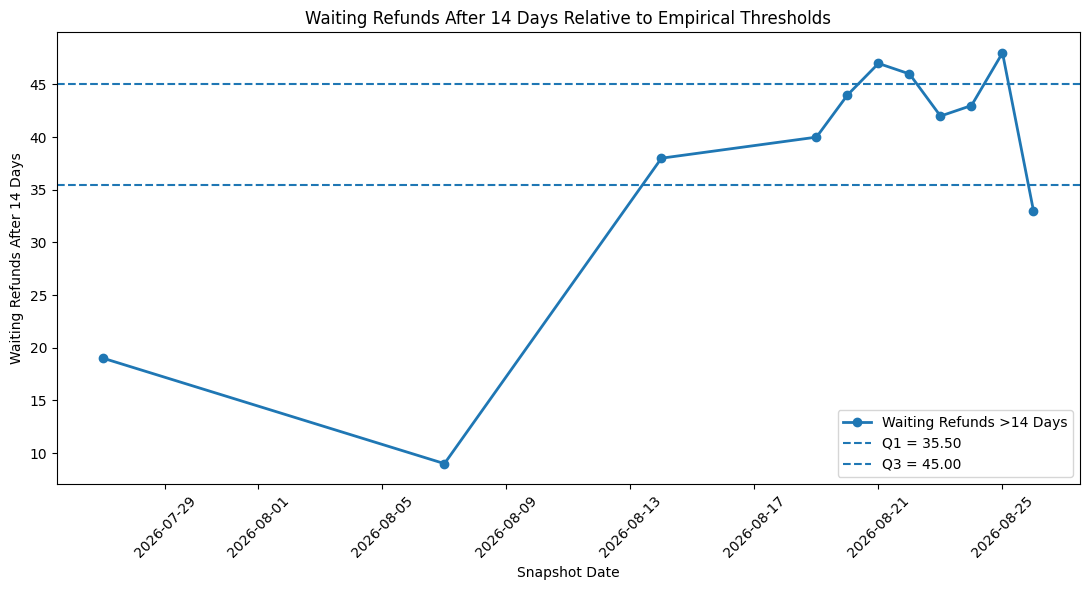

In [46]:
# ============================================================
# FIGURE 4.X:
# WAITING REFUNDS AGAINST THRESHOLDS
# ============================================================

kri3_plot = master_kri[
    [
        "date",
        "KRI3_waiting_refunds_after_14_days"
    ]
].dropna()


plt.figure(
    figsize=(11, 6)
)

plt.plot(
    kri3_plot["date"],
    kri3_plot[
        "KRI3_waiting_refunds_after_14_days"
    ],
    marker="o",
    linewidth=2,
    label="Waiting Refunds >14 Days"
)

plt.axhline(
    kri3_q1,
    linestyle="--",
    label=f"Q1 = {kri3_q1:.2f}"
)

plt.axhline(
    kri3_q3,
    linestyle="--",
    label=f"Q3 = {kri3_q3:.2f}"
)

plt.xlabel(
    "Snapshot Date"
)

plt.ylabel(
    "Waiting Refunds After 14 Days"
)

plt.title(
    "Waiting Refunds After 14 Days "
    "Relative to Empirical Thresholds"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Waiting_Refunds_Threshold_Classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 5I — Plot updated Chargebacks with thresholds**

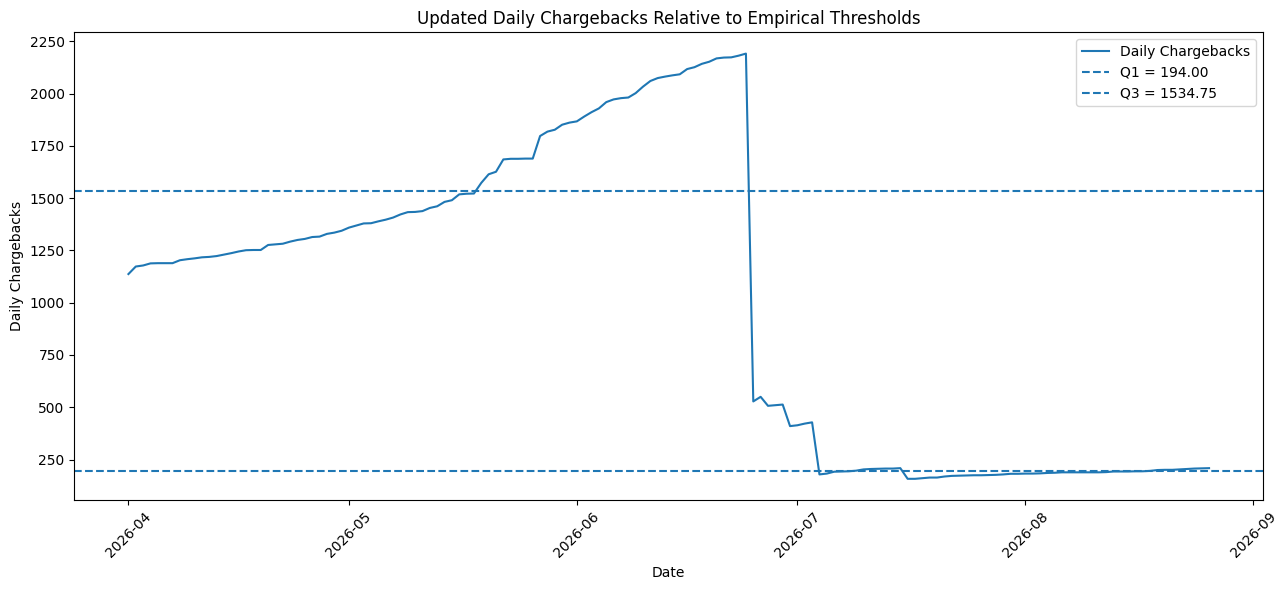

In [47]:
# ============================================================
# FIGURE 4.X:
# UPDATED CHARGEBACKS AGAINST THRESHOLDS
# ============================================================

kri4_plot = master_kri[
    [
        "date",
        "KRI4_chargebacks"
    ]
].dropna()


plt.figure(
    figsize=(13, 6)
)

plt.plot(
    kri4_plot["date"],
    kri4_plot["KRI4_chargebacks"],
    linewidth=1.5,
    label="Daily Chargebacks"
)

plt.axhline(
    kri4_q1,
    linestyle="--",
    label=f"Q1 = {kri4_q1:.2f}"
)

plt.axhline(
    kri4_q3,
    linestyle="--",
    label=f"Q3 = {kri4_q3:.2f}"
)

plt.xlabel("Date")

plt.ylabel(
    "Daily Chargebacks"
)

plt.title(
    "Updated Daily Chargebacks "
    "Relative to Empirical Thresholds"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Updated_Chargeback_Threshold_Classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 5J — Investigate whether Historical Refund Operations can create a better rate KRI**

In [48]:
# ============================================================
# STEP 5J: WAITING REFUNDS RELATIVE TO HISTORICAL
# REFUND OPERATIONS
# ============================================================

refund_rate_data = master_kri[
    [
        "date",
        "KRI3_waiting_refunds_after_14_days",
        "KRI5_historical_refund_operations"
    ]
].dropna().copy()


print(
    "Dates with both waiting-refund "
    "and historical-refund values:",
    len(refund_rate_data)
)


display(
    refund_rate_data
)

Dates with both waiting-refund and historical-refund values: 11


,date,KRI3_waiting_refunds_after_14_days,KRI5_historical_refund_operations
202,2026-07-27,19.0,1459
213,2026-08-07,9.0,1531
220,2026-08-14,38.0,456
225,2026-08-19,40.0,454
226,2026-08-20,44.0,454
227,2026-08-21,47.0,454
228,2026-08-22,46.0,454
229,2026-08-23,42.0,454
230,2026-08-24,43.0,454
231,2026-08-25,48.0,454


In [49]:
# ============================================================
# OPTIONAL NORMALIZED REFUND DELAY KRI
#
# Only use this if KRI5 is a valid denominator
# for KRI3.
# ============================================================

refund_rate_data[
    "Waiting_Refund_Rate_Percent"
] = (
    refund_rate_data[
        "KRI3_waiting_refunds_after_14_days"
    ]
    /
    refund_rate_data[
        "KRI5_historical_refund_operations"
    ]
    * 100
)


print(
    "\nWAITING REFUND RATE (%)"
)

display(
    refund_rate_data
)


WAITING REFUND RATE (%)


,date,KRI3_waiting_refunds_after_14_days,KRI5_historical_refund_operations,Waiting_Refund_Rate_Percent
202,2026-07-27,19.0,1459,1.302262
213,2026-08-07,9.0,1531,0.587851
220,2026-08-14,38.0,456,8.333333
225,2026-08-19,40.0,454,8.810573
226,2026-08-20,44.0,454,9.691630
227,2026-08-21,47.0,454,10.352423
228,2026-08-22,46.0,454,10.132159
229,2026-08-23,42.0,454,9.251101
230,2026-08-24,43.0,454,9.471366
231,2026-08-25,48.0,454,10.572687


**Step 5K — Save the partially scored master file**

In [50]:
# ============================================================
# STEP 5K: SAVE SCORED MASTER DATASET
# ============================================================

master_kri.to_csv(
    "/content/"
    "Master_Multi_KRI_With_Initial_Scores.csv",
    index=False
)

kri3_classification_table.to_csv(
    "/content/"
    "KRI3_Waiting_Refunds_Classification.csv",
    index=False
)

kri4_classification_table.to_csv(
    "/content/"
    "KRI4_Chargeback_Classification.csv",
    index=False
)

print(
    "Threshold and classification "
    "outputs saved successfully."
)

Threshold and classification outputs saved successfully.


**Step 6A — Load the scored master dataset**

In [51]:
# ============================================================
# STEP 6A: LOAD SCORED MASTER DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_kri = pd.read_csv(
    "/content/Master_Multi_KRI_With_Initial_Scores.csv"
)

master_kri["date"] = pd.to_datetime(
    master_kri["date"],
    errors="coerce"
)

master_kri = (
    master_kri
    .sort_values("date")
    .reset_index(drop=True)
)

print("Dataset shape:", master_kri.shape)

display(
    master_kri.head()
)

Dataset shape: (233, 11)


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations,Available_KRI_Count,KRI3_Class,KRI4_Class,KRI3_Score,KRI4_Score
0,2026-01-06,NaN,NaN,NaN,NaN,2,1,NaN,NaN,NaN,NaN
1,2026-01-07,NaN,NaN,NaN,NaN,3,1,NaN,NaN,NaN,NaN
2,2026-01-08,NaN,NaN,NaN,NaN,3,1,NaN,NaN,NaN,NaN
3,2026-01-09,NaN,NaN,NaN,NaN,3,1,NaN,NaN,NaN,NaN
4,2026-01-10,NaN,NaN,NaN,NaN,3,1,NaN,NaN,NaN,NaN


**Step 6B — Check scored KRI availability**

In [52]:
# ============================================================
# STEP 6B: CHECK SCORED KRI AVAILABILITY
# ============================================================

score_availability = pd.DataFrame({

    "KRI": [
        "Waiting Refunds After 14 Days",
        "Daily Chargebacks"
    ],

    "Score Column": [
        "KRI3_Score",
        "KRI4_Score"
    ],

    "Available Scores": [
        master_kri[
            "KRI3_Score"
        ].notna().sum(),

        master_kri[
            "KRI4_Score"
        ].notna().sum()
    ]
})

display(
    score_availability
)

,KRI,Score Column,Available Scores
0,Waiting Refunds After 14 Days,KRI3_Score,11
1,Daily Chargebacks,KRI4_Score,148


In [53]:
# ============================================================
# FIND COMMON KRI3/KRI4 DATES
# ============================================================

composite_data = master_kri[
    master_kri[
        [
            "KRI3_Score",
            "KRI4_Score"
        ]
    ]
    .notna()
    .all(axis=1)
].copy()


print(
    "Dates with both KRI3 and KRI4:",
    len(composite_data)
)

print(
    "Date range:",
    composite_data["date"].min(),
    "to",
    composite_data["date"].max()
)

display(
    composite_data[
        [
            "date",
            "KRI3_waiting_refunds_after_14_days",
            "KRI3_Class",
            "KRI3_Score",
            "KRI4_chargebacks",
            "KRI4_Class",
            "KRI4_Score"
        ]
    ]
)

Dates with both KRI3 and KRI4: 11
Date range: 2026-07-27 00:00:00 to 2026-08-26 00:00:00


,date,KRI3_waiting_refunds_after_14_days,KRI3_Class,KRI3_Score,KRI4_chargebacks,KRI4_Class,KRI4_Score
202,2026-07-27,19.0,Green,1.0,176.0,Green,1.0
213,2026-08-07,9.0,Green,1.0,189.0,Green,1.0
220,2026-08-14,38.0,Amber,2.0,193.0,Green,1.0
225,2026-08-19,40.0,Amber,2.0,200.0,Amber,2.0
226,2026-08-20,44.0,Amber,2.0,201.0,Amber,2.0
227,2026-08-21,47.0,Red,3.0,201.0,Amber,2.0
228,2026-08-22,46.0,Red,3.0,203.0,Amber,2.0
229,2026-08-23,42.0,Amber,2.0,205.0,Amber,2.0
230,2026-08-24,43.0,Amber,2.0,207.0,Amber,2.0
231,2026-08-25,48.0,Red,3.0,208.0,Amber,2.0


**Step 6C — Define model weights**

In [54]:
# ============================================================
# STEP 6C: CONFIGURE KRI WEIGHTS
# ============================================================

weights = {

    "KRI3_Score": 0.50,

    "KRI4_Score": 0.50
}


print("MODEL WEIGHTS")
print("=" * 50)

for kri, weight in weights.items():
    print(
        kri,
        "=",
        weight
    )


print(
    "\nTotal weight:",
    sum(weights.values())
)

MODEL WEIGHTS
KRI3_Score = 0.5
KRI4_Score = 0.5

Total weight: 1.0


**Step 6D — Calculate weighted KRI contributions**

In [55]:
# ============================================================
# STEP 6D: CALCULATE WEIGHTED CONTRIBUTIONS
# ============================================================

composite_data[
    "KRI3_Weighted"
] = (
    composite_data[
        "KRI3_Score"
    ]
    * weights[
        "KRI3_Score"
    ]
)


composite_data[
    "KRI4_Weighted"
] = (
    composite_data[
        "KRI4_Score"
    ]
    * weights[
        "KRI4_Score"
    ]
)


display(
    composite_data[
        [
            "date",
            "KRI3_Score",
            "KRI3_Weighted",
            "KRI4_Score",
            "KRI4_Weighted"
        ]
    ]
)

,date,KRI3_Score,KRI3_Weighted,KRI4_Score,KRI4_Weighted
202,2026-07-27,1.0,0.5,1.0,0.5
213,2026-08-07,1.0,0.5,1.0,0.5
220,2026-08-14,2.0,1.0,1.0,0.5
225,2026-08-19,2.0,1.0,2.0,1.0
226,2026-08-20,2.0,1.0,2.0,1.0
227,2026-08-21,3.0,1.5,2.0,1.0
228,2026-08-22,3.0,1.5,2.0,1.0
229,2026-08-23,2.0,1.0,2.0,1.0
230,2026-08-24,2.0,1.0,2.0,1.0
231,2026-08-25,3.0,1.5,2.0,1.0


**Step 6E — Calculate the composite RCSA KRI score**

In [56]:
# ============================================================
# STEP 6E: COMPOSITE RCSA KRI SCORE
# ============================================================

composite_data[
    "Composite_Risk_Score"
] = (

    composite_data[
        "KRI3_Weighted"
    ]

    +

    composite_data[
        "KRI4_Weighted"
    ]
)


composite_data[
    "Composite_Risk_Score"
] = (
    composite_data[
        "Composite_Risk_Score"
    ]
    .round(2)
)


print(
    "MULTI-KRI COMPOSITE SCORES"
)

display(
    composite_data[
        [
            "date",
            "KRI3_Score",
            "KRI4_Score",
            "Composite_Risk_Score"
        ]
    ]
)

MULTI-KRI COMPOSITE SCORES


,date,KRI3_Score,KRI4_Score,Composite_Risk_Score
202,2026-07-27,1.0,1.0,1.0
213,2026-08-07,1.0,1.0,1.0
220,2026-08-14,2.0,1.0,1.5
225,2026-08-19,2.0,2.0,2.0
226,2026-08-20,2.0,2.0,2.0
227,2026-08-21,3.0,2.0,2.5
228,2026-08-22,3.0,2.0,2.5
229,2026-08-23,2.0,2.0,2.0
230,2026-08-24,2.0,2.0,2.0
231,2026-08-25,3.0,2.0,2.5


**Step 6F — Convert the composite score into RAG status**

We will use:

Green: 1.00–1.49
Amber: 1.50–2.49
Red: 2.50–3.00

In [57]:
# ============================================================
# STEP 6F: COMPOSITE RISK CLASSIFICATION
# ============================================================

def classify_composite(score):

    if pd.isna(score):
        return np.nan

    if score < 1.50:
        return "Green"

    elif score < 2.50:
        return "Amber"

    else:
        return "Red"


composite_data[
    "Composite_Class"
] = (
    composite_data[
        "Composite_Risk_Score"
    ]
    .apply(
        classify_composite
    )
)


display(
    composite_data[
        [
            "date",
            "KRI3_Class",
            "KRI4_Class",
            "Composite_Risk_Score",
            "Composite_Class"
        ]
    ]
)

,date,KRI3_Class,KRI4_Class,Composite_Risk_Score,Composite_Class
202,2026-07-27,Green,Green,1.0,Green
213,2026-08-07,Green,Green,1.0,Green
220,2026-08-14,Amber,Green,1.5,Amber
225,2026-08-19,Amber,Amber,2.0,Amber
226,2026-08-20,Amber,Amber,2.0,Amber
227,2026-08-21,Red,Amber,2.5,Red
228,2026-08-22,Red,Amber,2.5,Red
229,2026-08-23,Amber,Amber,2.0,Amber
230,2026-08-24,Amber,Amber,2.0,Amber
231,2026-08-25,Red,Amber,2.5,Red


**Step 6G — Create the composite classification distribution**

In [58]:
# ============================================================
# STEP 6G: COMPOSITE CLASSIFICATION SUMMARY
# ============================================================

composite_counts = (
    composite_data[
        "Composite_Class"
    ]
    .value_counts()
    .reindex(
        [
            "Green",
            "Amber",
            "Red"
        ],
        fill_value=0
    )
)


composite_percentage = (
    composite_counts
    / composite_counts.sum()
    * 100
).round(2)


composite_summary = pd.DataFrame({

    "Composite Classification": [
        "Green",
        "Amber",
        "Red"
    ],

    "Observations": [
        composite_counts["Green"],
        composite_counts["Amber"],
        composite_counts["Red"]
    ],

    "Percentage (%)": [
        composite_percentage["Green"],
        composite_percentage["Amber"],
        composite_percentage["Red"]
    ]
})


print(
    "TABLE: MULTI-KRI COMPOSITE "
    "RISK CLASSIFICATION"
)

display(
    composite_summary
)

TABLE: MULTI-KRI COMPOSITE RISK CLASSIFICATION


,Composite Classification,Observations,Percentage (%)
0,Green,2,18.18
1,Amber,6,54.55
2,Red,3,27.27


**Step 6H — Add RCSA decision-support signals**

In [59]:
# ============================================================
# STEP 6H: RCSA DECISION-SUPPORT LOGIC
# ============================================================

def rcsa_signal(risk_class):

    if risk_class == "Green":

        return (
            "Routine monitoring; "
            "retain current RCSA assessment "
            "unless other evidence indicates "
            "increased exposure."
        )

    elif risk_class == "Amber":

        return (
            "Enhanced monitoring; "
            "review trends, controls, and "
            "whether the current RCSA rating "
            "remains appropriate."
        )

    elif risk_class == "Red":

        return (
            "RCSA review/escalation; "
            "investigate drivers, assess control "
            "effectiveness, and consider whether "
            "gross or residual risk requires revision."
        )

    else:

        return np.nan


composite_data[
    "RCSA_Decision_Support"
] = (
    composite_data[
        "Composite_Class"
    ]
    .apply(
        rcsa_signal
    )
)


display(
    composite_data[
        [
            "date",
            "Composite_Risk_Score",
            "Composite_Class",
            "RCSA_Decision_Support"
        ]
    ]
)

,date,Composite_Risk_Score,Composite_Class,RCSA_Decision_Support
202,2026-07-27,1.0,Green,Routine monitoring; retain current RCSA assess...
213,2026-08-07,1.0,Green,Routine monitoring; retain current RCSA assess...
220,2026-08-14,1.5,Amber,"Enhanced monitoring; review trends, controls, ..."
225,2026-08-19,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
226,2026-08-20,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
227,2026-08-21,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
228,2026-08-22,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
229,2026-08-23,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
230,2026-08-24,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
231,2026-08-25,2.5,Red,"RCSA review/escalation; investigate drivers, a..."


**Step 6I — Create the evidence trail**

In [60]:
# ============================================================
# STEP 6I: CREATE RCSA EVIDENCE TRAIL
# ============================================================

evidence_trail = composite_data[
    [
        "date",

        "KRI3_waiting_refunds_after_14_days",
        "KRI3_Class",
        "KRI3_Score",
        "KRI3_Weighted",

        "KRI4_chargebacks",
        "KRI4_Class",
        "KRI4_Score",
        "KRI4_Weighted",

        "Composite_Risk_Score",
        "Composite_Class",
        "RCSA_Decision_Support"
    ]
].copy()


print(
    "MULTI-KRI RCSA EVIDENCE TRAIL"
)

display(
    evidence_trail
)

MULTI-KRI RCSA EVIDENCE TRAIL


,date,KRI3_waiting_refunds_after_14_days,KRI3_Class,KRI3_Score,KRI3_Weighted,KRI4_chargebacks,KRI4_Class,KRI4_Score,KRI4_Weighted,Composite_Risk_Score,Composite_Class,RCSA_Decision_Support
202,2026-07-27,19.0,Green,1.0,0.5,176.0,Green,1.0,0.5,1.0,Green,Routine monitoring; retain current RCSA assess...
213,2026-08-07,9.0,Green,1.0,0.5,189.0,Green,1.0,0.5,1.0,Green,Routine monitoring; retain current RCSA assess...
220,2026-08-14,38.0,Amber,2.0,1.0,193.0,Green,1.0,0.5,1.5,Amber,"Enhanced monitoring; review trends, controls, ..."
225,2026-08-19,40.0,Amber,2.0,1.0,200.0,Amber,2.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
226,2026-08-20,44.0,Amber,2.0,1.0,201.0,Amber,2.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
227,2026-08-21,47.0,Red,3.0,1.5,201.0,Amber,2.0,1.0,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
228,2026-08-22,46.0,Red,3.0,1.5,203.0,Amber,2.0,1.0,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
229,2026-08-23,42.0,Amber,2.0,1.0,205.0,Amber,2.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
230,2026-08-24,43.0,Amber,2.0,1.0,207.0,Amber,2.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
231,2026-08-25,48.0,Red,3.0,1.5,208.0,Amber,2.0,1.0,2.5,Red,"RCSA review/escalation; investigate drivers, a..."


**Step 6J — Create Figure: Multi-KRI Composite Risk Score**

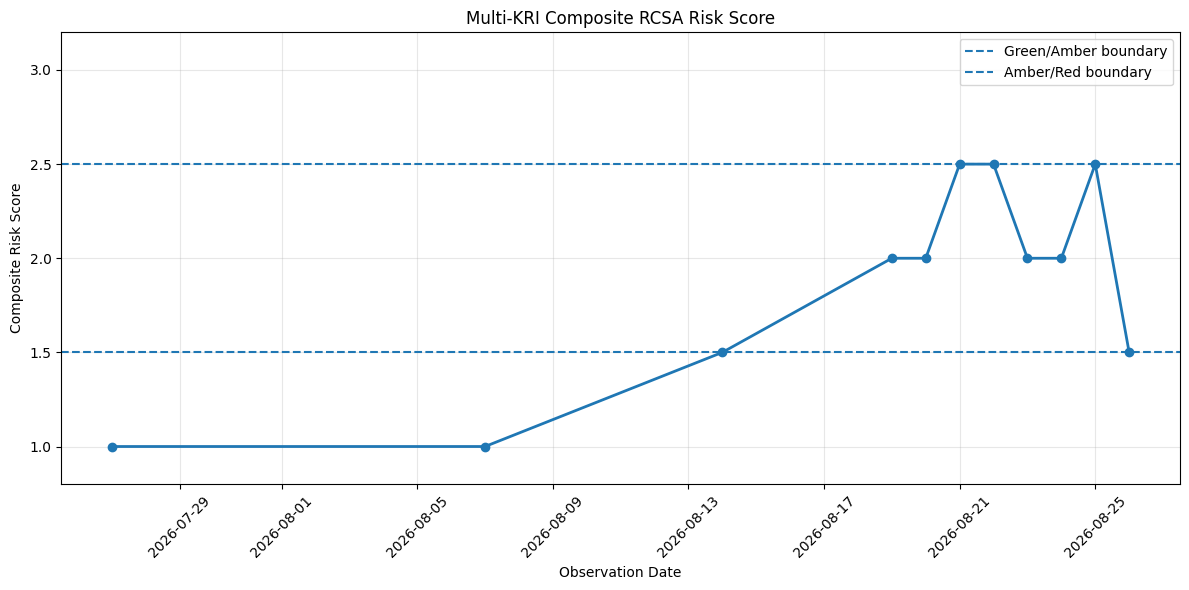

In [61]:
# ============================================================
# FIGURE:
# MULTI-KRI COMPOSITE RISK SCORE
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    composite_data["date"],
    composite_data[
        "Composite_Risk_Score"
    ],
    marker="o",
    linewidth=2
)


plt.axhline(
    1.5,
    linestyle="--",
    label="Green/Amber boundary"
)


plt.axhline(
    2.5,
    linestyle="--",
    label="Amber/Red boundary"
)


plt.xlabel(
    "Observation Date"
)

plt.ylabel(
    "Composite Risk Score"
)

plt.title(
    "Multi-KRI Composite RCSA Risk Score"
)

plt.ylim(
    0.8,
    3.2
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "/content/"
    "Figure_Multi_KRI_Composite_Risk_Score.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

**Step 6K — Identify highest-risk composite observations**

In [62]:
# ============================================================
# STEP 6K: HIGHEST RISK OBSERVATIONS
# ============================================================

highest_risk = (
    composite_data[
        [
            "date",
            "KRI3_waiting_refunds_after_14_days",
            "KRI3_Class",
            "KRI4_chargebacks",
            "KRI4_Class",
            "Composite_Risk_Score",
            "Composite_Class"
        ]
    ]
    .sort_values(
        "Composite_Risk_Score",
        ascending=False
    )
)


print(
    "HIGHEST COMPOSITE RISK OBSERVATIONS"
)

display(
    highest_risk.head(10)
)

HIGHEST COMPOSITE RISK OBSERVATIONS


,date,KRI3_waiting_refunds_after_14_days,KRI3_Class,KRI4_chargebacks,KRI4_Class,Composite_Risk_Score,Composite_Class
231,2026-08-25,48.0,Red,208.0,Amber,2.5,Red
227,2026-08-21,47.0,Red,201.0,Amber,2.5,Red
228,2026-08-22,46.0,Red,203.0,Amber,2.5,Red
225,2026-08-19,40.0,Amber,200.0,Amber,2.0,Amber
229,2026-08-23,42.0,Amber,205.0,Amber,2.0,Amber
230,2026-08-24,43.0,Amber,207.0,Amber,2.0,Amber
226,2026-08-20,44.0,Amber,201.0,Amber,2.0,Amber
220,2026-08-14,38.0,Amber,193.0,Green,1.5,Amber
232,2026-08-26,33.0,Green,209.0,Amber,1.5,Amber
213,2026-08-07,9.0,Green,189.0,Green,1.0,Green


**Step 6L — Test different weights**

In [63]:
# ============================================================
# STEP 6L: WEIGHT SENSITIVITY ANALYSIS
# ============================================================

weight_scenarios = {

    "Equal 50/50": (
        0.50,
        0.50
    ),

    "Refund-Focused 60/40": (
        0.60,
        0.40
    ),

    "Chargeback-Focused 40/60": (
        0.40,
        0.60
    )
}


sensitivity_results = []


for scenario, (
    w_kri3,
    w_kri4
) in weight_scenarios.items():

    temp_score = (

        composite_data[
            "KRI3_Score"
        ]
        * w_kri3

        +

        composite_data[
            "KRI4_Score"
        ]
        * w_kri4
    )

    temp_class = (
        temp_score
        .apply(
            classify_composite
        )
    )


    sensitivity_results.append({

        "Scenario": scenario,

        "KRI3 Weight":
            w_kri3,

        "KRI4 Weight":
            w_kri4,

        "Mean Composite Score":
            round(
                temp_score.mean(),
                3
            ),

        "Green":
            (temp_class == "Green").sum(),

        "Amber":
            (temp_class == "Amber").sum(),

        "Red":
            (temp_class == "Red").sum()
    })


sensitivity_table = pd.DataFrame(
    sensitivity_results
)


print(
    "WEIGHT SENSITIVITY ANALYSIS"
)

display(
    sensitivity_table
)

WEIGHT SENSITIVITY ANALYSIS


,Scenario,KRI3 Weight,KRI4 Weight,Mean Composite Score,Green,Amber,Red
0,Equal 50/50,0.5,0.5,1.864,2,6,3
1,Refund-Focused 60/40,0.6,0.4,1.891,3,5,3
2,Chargeback-Focused 40/60,0.4,0.6,1.836,3,8,0


**Step 6M — Repeatability test**

In [64]:
# ============================================================
# STEP 6M: MODEL REPEATABILITY TEST
# ============================================================

def run_composite_model(df):

    result = df.copy()

    result[
        "KRI3_Weighted_Test"
    ] = (
        result[
            "KRI3_Score"
        ] * 0.50
    )

    result[
        "KRI4_Weighted_Test"
    ] = (
        result[
            "KRI4_Score"
        ] * 0.50
    )

    result[
        "Composite_Test"
    ] = (

        result[
            "KRI3_Weighted_Test"
        ]

        +

        result[
            "KRI4_Weighted_Test"
        ]
    )

    result[
        "Class_Test"
    ] = (
        result[
            "Composite_Test"
        ]
        .apply(
            classify_composite
        )
    )

    return result[
        "Class_Test"
    ]


original_result = (
    composite_data[
        "Composite_Class"
    ]
    .reset_index(drop=True)
)


repeatability_rows = []


for run_number in range(
    2,
    6
):

    rerun_result = (
        run_composite_model(
            composite_data
        )
        .reset_index(drop=True)
    )

    matches = (
        original_result
        == rerun_result
    ).sum()

    total = len(
        original_result
    )

    agreement = (
        matches
        / total
        * 100
    )

    repeatability_rows.append({

        "Comparison":
            f"Original vs Run {run_number}",

        "Observations":
            total,

        "Matching Classifications":
            matches,

        "Agreement (%)":
            round(
                agreement,
                2
            )
    })


repeatability_table = pd.DataFrame(
    repeatability_rows
)


print(
    "MODEL REPEATABILITY TEST"
)

display(
    repeatability_table
)

MODEL REPEATABILITY TEST


,Comparison,Observations,Matching Classifications,Agreement (%)
0,Original vs Run 2,11,11,100.0
1,Original vs Run 3,11,11,100.0
2,Original vs Run 4,11,11,100.0
3,Original vs Run 5,11,11,100.0


**Step 6N — Optional: derive a refund-delay rate**

In [65]:
# ============================================================
# STEP 6N: OPTIONAL REFUND DELAY RATE
# ============================================================

refund_rate = master_kri[
    [
        "date",
        "KRI3_waiting_refunds_after_14_days",
        "KRI5_historical_refund_operations"
    ]
].dropna().copy()


refund_rate = refund_rate[
    refund_rate[
        "KRI5_historical_refund_operations"
    ] > 0
].copy()


refund_rate[
    "Refund_Delay_Rate_Percent"
] = (

    refund_rate[
        "KRI3_waiting_refunds_after_14_days"
    ]

    /

    refund_rate[
        "KRI5_historical_refund_operations"
    ]

    * 100
)


print(
    "POTENTIAL REFUND DELAY RATE"
)

display(
    refund_rate
)

POTENTIAL REFUND DELAY RATE


,date,KRI3_waiting_refunds_after_14_days,KRI5_historical_refund_operations,Refund_Delay_Rate_Percent
202,2026-07-27,19.0,1459,1.302262
213,2026-08-07,9.0,1531,0.587851
220,2026-08-14,38.0,456,8.333333
225,2026-08-19,40.0,454,8.810573
226,2026-08-20,44.0,454,9.691630
227,2026-08-21,47.0,454,10.352423
228,2026-08-22,46.0,454,10.132159
229,2026-08-23,42.0,454,9.251101
230,2026-08-24,43.0,454,9.471366
231,2026-08-25,48.0,454,10.572687


**Step 6O — Save the model outputs**

In [66]:
# ============================================================
# STEP 6O: SAVE MULTI-KRI MODEL OUTPUTS
# ============================================================

composite_data.to_csv(
    "/content/"
    "Multi_KRI_Composite_Model_Output.csv",
    index=False
)


evidence_trail.to_csv(
    "/content/"
    "Multi_KRI_RCSA_Evidence_Trail.csv",
    index=False
)


composite_summary.to_csv(
    "/content/"
    "Multi_KRI_Composite_Classification_Summary.csv",
    index=False
)


sensitivity_table.to_csv(
    "/content/"
    "Multi_KRI_Weight_Sensitivity.csv",
    index=False
)


repeatability_table.to_csv(
    "/content/"
    "Multi_KRI_Repeatability_Test.csv",
    index=False
)


print(
    "All Step 6 model outputs saved successfully."
)

All Step 6 model outputs saved successfully.


**Model Training**

**Step 7A — Load the daily KRI4/KRI5 data**

In [67]:
# ============================================================
# STEP 7A: LOAD DAILY KRI4 + KRI5 DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

daily_data = pd.read_csv(
    "/content/KRI4_KRI5_Daily_Overlap.csv"
)

daily_data["date"] = pd.to_datetime(
    daily_data["date"],
    errors="coerce"
)

daily_data["KRI4_chargebacks"] = pd.to_numeric(
    daily_data["KRI4_chargebacks"],
    errors="coerce"
)

daily_data["KRI5_historical_refund_operations"] = pd.to_numeric(
    daily_data["KRI5_historical_refund_operations"],
    errors="coerce"
)

daily_data = (
    daily_data
    .dropna(
        subset=[
            "date",
            "KRI4_chargebacks",
            "KRI5_historical_refund_operations"
        ]
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("Daily observations:", len(daily_data))

print(
    "Date range:",
    daily_data["date"].min(),
    "to",
    daily_data["date"].max()
)

display(daily_data.head())

Daily observations: 148
Date range: 2026-04-01 00:00:00 to 2026-08-26 00:00:00


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations,Available_KRI_Count
0,2026-04-01,NaN,NaN,NaN,1137.0,9,2
1,2026-04-02,NaN,NaN,NaN,1173.0,10,2
2,2026-04-03,NaN,NaN,NaN,1178.0,10,2
3,2026-04-04,NaN,NaN,NaN,1188.0,9,2
4,2026-04-05,NaN,NaN,NaN,1189.0,9,2


**Step 7B — Create the next-day prediction target**

In [68]:
# ============================================================
# STEP 7B: CREATE NEXT-DAY TARGET
# ============================================================

daily_data[
    "target_date"
] = daily_data["date"].shift(-1)

daily_data[
    "next_day_refund_operations"
] = (
    daily_data[
        "KRI5_historical_refund_operations"
    ]
    .shift(-1)
)

display(
    daily_data[
        [
            "date",
            "KRI5_historical_refund_operations",
            "target_date",
            "next_day_refund_operations"
        ]
    ].head(10)
)

,date,KRI5_historical_refund_operations,target_date,next_day_refund_operations
0,2026-04-01,9,2026-04-02,10.0
1,2026-04-02,10,2026-04-03,10.0
2,2026-04-03,10,2026-04-04,9.0
3,2026-04-04,9,2026-04-05,9.0
4,2026-04-05,9,2026-04-06,9.0
5,2026-04-06,9,2026-04-07,9.0
6,2026-04-07,9,2026-04-08,9.0
7,2026-04-08,9,2026-04-09,9.0
8,2026-04-09,9,2026-04-10,9.0
9,2026-04-10,9,2026-04-11,9.0


**Step 7C — Feature engineering**

In [69]:
# ============================================================
# STEP 7C: FEATURE ENGINEERING
# ============================================================

df = daily_data.copy()

# ------------------------------------------------------------
# Current observations
# ------------------------------------------------------------

df["current_chargebacks"] = (
    df["KRI4_chargebacks"]
)

df["current_refund_operations"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
)


# ------------------------------------------------------------
# CHARGEBACK LAGS
# ------------------------------------------------------------

for lag in [1, 2, 3, 7]:

    df[
        f"chargeback_lag_{lag}"
    ] = (
        df["KRI4_chargebacks"]
        .shift(lag)
    )


# ------------------------------------------------------------
# REFUND OPERATION LAGS
# ------------------------------------------------------------

for lag in [1, 2, 3, 7]:

    df[
        f"refund_lag_{lag}"
    ] = (
        df[
            "KRI5_historical_refund_operations"
        ]
        .shift(lag)
    )


# ------------------------------------------------------------
# MOVING AVERAGES
# ------------------------------------------------------------

df["chargeback_mean_3"] = (
    df["KRI4_chargebacks"]
    .rolling(3)
    .mean()
)

df["chargeback_mean_7"] = (
    df["KRI4_chargebacks"]
    .rolling(7)
    .mean()
)

df["refund_mean_3"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
    .rolling(3)
    .mean()
)

df["refund_mean_7"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
    .rolling(7)
    .mean()
)


# ------------------------------------------------------------
# VOLATILITY
# ------------------------------------------------------------

df["chargeback_std_7"] = (
    df["KRI4_chargebacks"]
    .rolling(7)
    .std()
)

df["refund_std_7"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
    .rolling(7)
    .std()
)


# ------------------------------------------------------------
# SHORT-TERM CHANGES
# ------------------------------------------------------------

df["chargeback_change_1"] = (
    df["KRI4_chargebacks"]
    .diff(1)
)

df["chargeback_change_3"] = (
    df["KRI4_chargebacks"]
    .diff(3)
)

df["refund_change_1"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
    .diff(1)
)

df["refund_change_3"] = (
    df[
        "KRI5_historical_refund_operations"
    ]
    .diff(3)
)


# ------------------------------------------------------------
# DAY OF WEEK
# ------------------------------------------------------------

df["day_of_week"] = (
    df["date"].dt.dayofweek
)

df["day_sin"] = np.sin(
    2 * np.pi
    * df["day_of_week"]
    / 7
)

df["day_cos"] = np.cos(
    2 * np.pi
    * df["day_of_week"]
    / 7
)

**Step 7D — Define the predictor variables**

In [70]:
# ============================================================
# STEP 7D: DEFINE MODEL FEATURES
# ============================================================

features = [

    "current_chargebacks",
    "current_refund_operations",

    "chargeback_lag_1",
    "chargeback_lag_2",
    "chargeback_lag_3",
    "chargeback_lag_7",

    "refund_lag_1",
    "refund_lag_2",
    "refund_lag_3",
    "refund_lag_7",

    "chargeback_mean_3",
    "chargeback_mean_7",

    "refund_mean_3",
    "refund_mean_7",

    "chargeback_std_7",
    "refund_std_7",

    "chargeback_change_1",
    "chargeback_change_3",

    "refund_change_1",
    "refund_change_3",

    "day_sin",
    "day_cos"
]


model_df = df[
    [
        "date",
        "target_date",
        "next_day_refund_operations"
    ]
    + features
].dropna().copy()


print(
    "Usable modelling observations:",
    len(model_df)
)

print(
    "Modelling date range:",
    model_df["date"].min(),
    "to",
    model_df["date"].max()
)

display(model_df.head())

Usable modelling observations: 140
Modelling date range: 2026-04-08 00:00:00 to 2026-08-25 00:00:00


,date,target_date,next_day_refund_operations,current_chargebacks,current_refund_operations,chargeback_lag_1,chargeback_lag_2,chargeback_lag_3,chargeback_lag_7,refund_lag_1,...,refund_mean_3,refund_mean_7,chargeback_std_7,refund_std_7,chargeback_change_1,chargeback_change_3,refund_change_1,refund_change_3,day_sin,day_cos
7,2026-04-08,2026-04-09,9.0,1203.0,9,1189.0,1189.0,1189.0,1137.0,9.0,...,9.0,9.285714,9.539392,0.487950,14.0,14.0,0.0,0.0,0.974928,-0.222521
8,2026-04-09,2026-04-10,9.0,1208.0,9,1203.0,1189.0,1189.0,1173.0,9.0,...,9.0,9.142857,10.132456,0.377964,5.0,19.0,0.0,0.0,0.433884,-0.900969
9,2026-04-10,2026-04-11,9.0,1212.0,9,1208.0,1203.0,1189.0,1178.0,9.0,...,9.0,9.000000,10.447146,0.000000,4.0,23.0,0.0,0.0,-0.433884,-0.900969
10,2026-04-11,2026-04-12,9.0,1217.0,9,1212.0,1208.0,1203.0,1188.0,9.0,...,9.0,9.000000,11.986103,0.000000,5.0,14.0,0.0,0.0,-0.974928,-0.222521
11,2026-04-12,2026-04-13,9.0,1219.0,9,1217.0,1212.0,1208.0,1189.0,9.0,...,9.0,9.000000,12.338480,0.000000,2.0,11.0,0.0,0.0,-0.781831,0.623490


**Step 7E — Chronological train/test split**

In [71]:
# ============================================================
# STEP 7E: CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_index = int(
    len(model_df) * 0.80
)

train_df = (
    model_df
    .iloc[:split_index]
    .copy()
)

test_df = (
    model_df
    .iloc[split_index:]
    .copy()
)


X_train = train_df[features]

y_train = train_df[
    "next_day_refund_operations"
]


X_test = test_df[features]

y_test = test_df[
    "next_day_refund_operations"
]


print("=" * 60)
print("TRAINING SET")
print("=" * 60)

print(
    "Observations:",
    len(train_df)
)

print(
    "Target dates:",
    train_df["target_date"].min(),
    "to",
    train_df["target_date"].max()
)


print("\n" + "=" * 60)
print("TEST SET")
print("=" * 60)

print(
    "Observations:",
    len(test_df)
)

print(
    "Target dates:",
    test_df["target_date"].min(),
    "to",
    test_df["target_date"].max()
)

TRAINING SET
Observations: 112
Target dates: 2026-04-09 00:00:00 to 2026-07-29 00:00:00

TEST SET
Observations: 28
Target dates: 2026-07-30 00:00:00 to 2026-08-26 00:00:00


**Step 7F — Model 1: Ridge Regression**

In [72]:
# ============================================================
# STEP 7F: RIDGE REGRESSION
# ============================================================

ridge_model = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "ridge",
        Ridge(
            alpha=1.0
        )
    )
])


ridge_model.fit(
    X_train,
    y_train
)


ridge_pred = ridge_model.predict(
    X_test
)

print(
    "Ridge model trained successfully."
)

Ridge model trained successfully.


**Step 7G — Model 2: Random Forest Regression**

In [74]:
# ============================================================
# STEP 7G: RANDOM FOREST REGRESSION
# ============================================================

rf_model = RandomForestRegressor(

    n_estimators=500,

    max_depth=6,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)


rf_model.fit(
    X_train,
    y_train
)


rf_pred = rf_model.predict(
    X_test
)

print(
    "Random Forest model trained successfully."
)

Random Forest model trained successfully.


**Step 7H — Define regression performance measures**

In [75]:
# ============================================================
# STEP 7H: MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_regression(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    # Avoid division by zero
    non_zero = actual != 0

    if non_zero.sum() > 0:

        mape = np.mean(
            np.abs(
                (
                    actual[non_zero]
                    -
                    predicted[non_zero]
                )
                /
                actual[non_zero]
            )
        ) * 100

    else:

        mape = np.nan


    return {

        "Model":
            model_name,

        "MAE":
            mae,

        "RMSE":
            rmse,

        "R2":
            r2,

        "MAPE (%)":
            mape
    }

**Step 7I — Compare Ridge and Random Forest**

In [76]:
# ============================================================
# STEP 7I: MODEL COMPARISON
# ============================================================

ridge_results = evaluate_regression(
    "Ridge Regression",
    y_test.reset_index(drop=True),
    ridge_pred
)


rf_results = evaluate_regression(
    "Random Forest Regression",
    y_test.reset_index(drop=True),
    rf_pred
)


performance_table = pd.DataFrame([
    ridge_results,
    rf_results
])


performance_table[
    [
        "MAE",
        "RMSE",
        "R2",
        "MAPE (%)"
    ]
] = performance_table[
    [
        "MAE",
        "RMSE",
        "R2",
        "MAPE (%)"
    ]
].round(4)


print(
    "\nPREDICTIVE MODEL PERFORMANCE"
)

display(
    performance_table
)


PREDICTIVE MODEL PERFORMANCE


,Model,MAE,RMSE,R2,MAPE (%)
0,Ridge Regression,82.7705,199.6577,0.8528,15.3282
1,Random Forest Regression,439.5718,450.5578,0.2503,77.6432


**Step 7J — Select the best model**

In [77]:
# ============================================================
# STEP 7J: SELECT BEST MODEL
# ============================================================

ranked_models = (
    performance_table
    .sort_values(
        by=[
            "RMSE",
            "MAE",
            "MAPE (%)"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


best_model_name = (
    ranked_models.loc[
        0,
        "Model"
    ]
)


print("=" * 60)

print(
    "SELECTED PREDICTIVE MODEL:"
)

print(
    best_model_name
)

print("=" * 60)

display(
    ranked_models
)

SELECTED PREDICTIVE MODEL:
Ridge Regression


,Model,MAE,RMSE,R2,MAPE (%)
0,Ridge Regression,82.7705,199.6577,0.8528,15.3282
1,Random Forest Regression,439.5718,450.5578,0.2503,77.6432


**Step 7K — Actual versus predicted values**

In [78]:
# ============================================================
# STEP 7K: ACTUAL VS PREDICTED
# ============================================================

prediction_results = pd.DataFrame({

    "Target_Date":
        test_df[
            "target_date"
        ].values,

    "Actual_Refund_Operations":
        y_test.values,

    "Ridge_Prediction":
        ridge_pred,

    "Random_Forest_Prediction":
        rf_pred
})


prediction_results[
    "Ridge_Error"
] = (
    prediction_results[
        "Actual_Refund_Operations"
    ]
    -
    prediction_results[
        "Ridge_Prediction"
    ]
)


prediction_results[
    "Random_Forest_Error"
] = (
    prediction_results[
        "Actual_Refund_Operations"
    ]
    -
    prediction_results[
        "Random_Forest_Prediction"
    ]
)


print(
    "FIRST 20 TEST PREDICTIONS"
)

display(
    prediction_results.head(20)
)

FIRST 20 TEST PREDICTIONS


,Target_Date,Actual_Refund_Operations,Ridge_Prediction,Random_Forest_Prediction,Ridge_Error,Random_Forest_Error
0,2026-07-30,1611.0,1579.502747,1366.534617,31.497253,244.465383
1,2026-07-31,1603.0,1634.165778,1365.428902,-31.165778,237.571098
2,2026-08-01,1557.0,1628.037717,1213.225725,-71.037717,343.774275
3,2026-08-02,1521.0,1584.087657,1176.885411,-63.087657,344.114589
4,2026-08-03,1532.0,1565.360161,1181.508947,-33.360161,350.491053
5,2026-08-04,1551.0,1587.256888,1154.212949,-36.256888,396.787051
6,2026-08-05,1526.0,1609.050934,1144.171780,-83.050934,381.828220
7,2026-08-06,1516.0,1569.803805,1126.421078,-53.803805,389.578922
8,2026-08-07,1531.0,1533.784071,1126.886366,-2.784071,404.113634
9,2026-08-08,1451.0,1541.594710,1126.422366,-90.594710,324.577634


**Step 7L — Plot Ridge predictions**

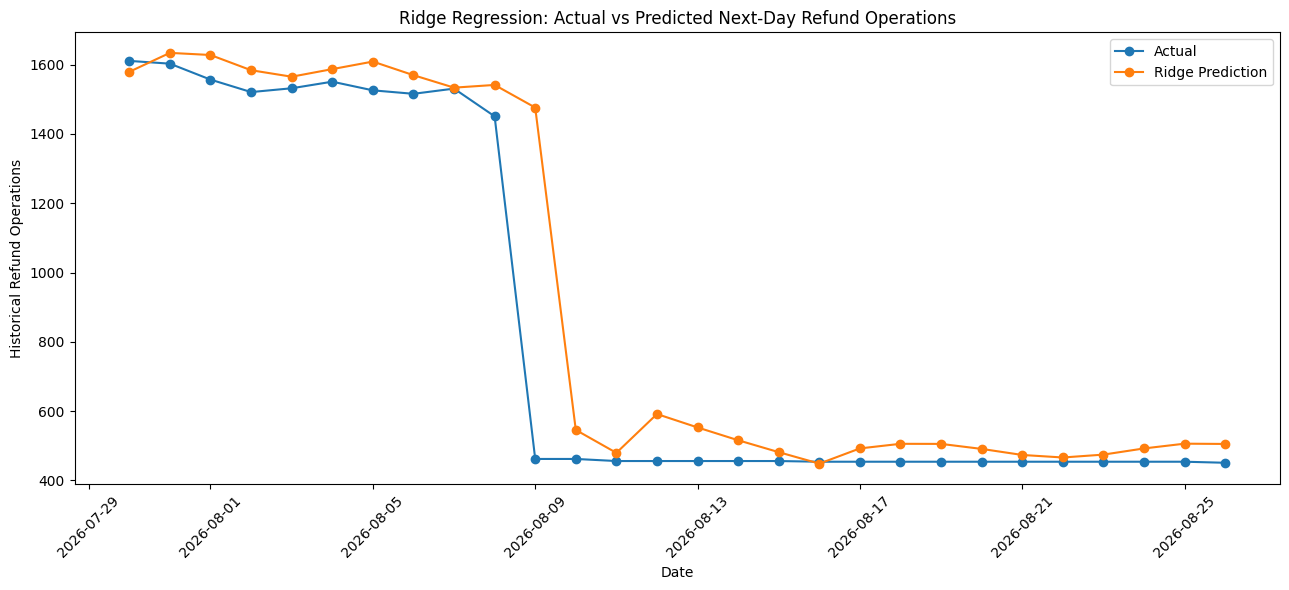

In [79]:
# ============================================================
# FIGURE: RIDGE REGRESSION
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    prediction_results[
        "Target_Date"
    ],
    prediction_results[
        "Actual_Refund_Operations"
    ],
    marker="o",
    label="Actual"
)

plt.plot(
    prediction_results[
        "Target_Date"
    ],
    prediction_results[
        "Ridge_Prediction"
    ],
    marker="o",
    label="Ridge Prediction"
)

plt.xlabel("Date")

plt.ylabel(
    "Historical Refund Operations"
)

plt.title(
    "Ridge Regression: Actual vs Predicted "
    "Next-Day Refund Operations"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Ridge_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 7M — Plot Random Forest predictions**

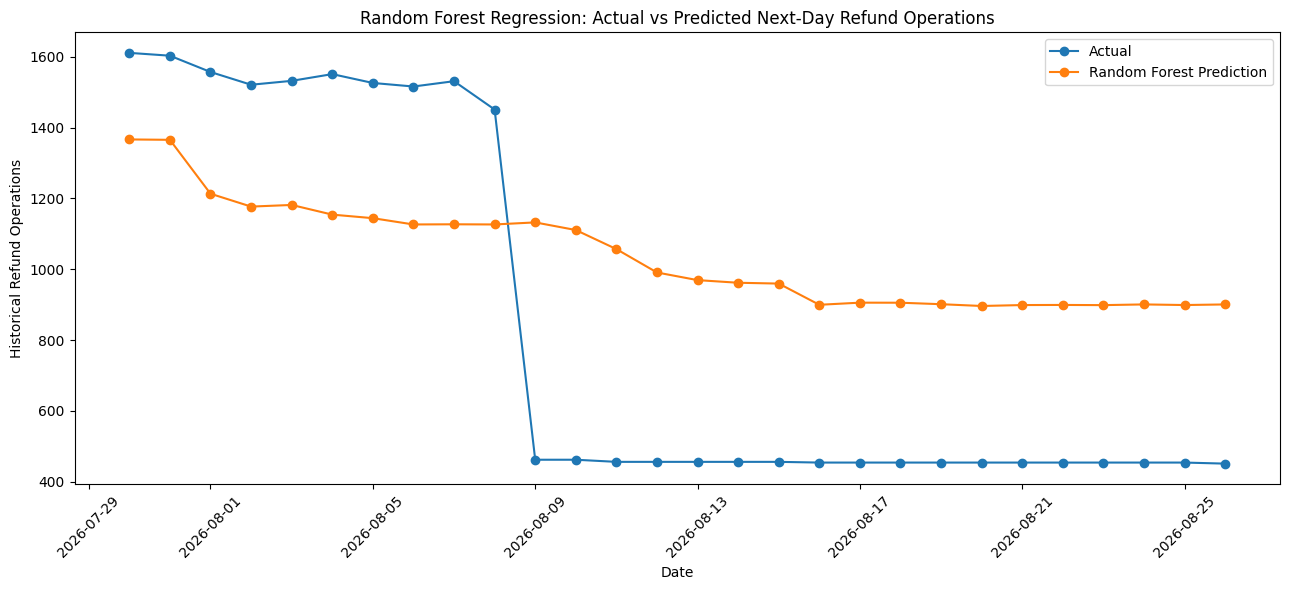

In [80]:
# ============================================================
# FIGURE: RANDOM FOREST
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(13, 6)
)

plt.plot(
    prediction_results[
        "Target_Date"
    ],
    prediction_results[
        "Actual_Refund_Operations"
    ],
    marker="o",
    label="Actual"
)

plt.plot(
    prediction_results[
        "Target_Date"
    ],
    prediction_results[
        "Random_Forest_Prediction"
    ],
    marker="o",
    label="Random Forest Prediction"
)

plt.xlabel("Date")

plt.ylabel(
    "Historical Refund Operations"
)

plt.title(
    "Random Forest Regression: "
    "Actual vs Predicted Next-Day Refund Operations"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Random_Forest_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 7N — Random Forest feature importance**

In [81]:
# ============================================================
# STEP 7N: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature":
        features,

    "Importance":
        rf_model.feature_importances_
})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "RANDOM FOREST FEATURE IMPORTANCE"
)

display(
    feature_importance
)

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,chargeback_mean_7,0.146941
1,refund_lag_3,0.139716
2,refund_mean_7,0.138301
3,refund_lag_2,0.124608
4,refund_mean_3,0.122728
5,current_refund_operations,0.110859
6,chargeback_lag_3,0.051629
7,refund_lag_1,0.050334
8,refund_std_7,0.030938
9,chargeback_lag_2,0.025444


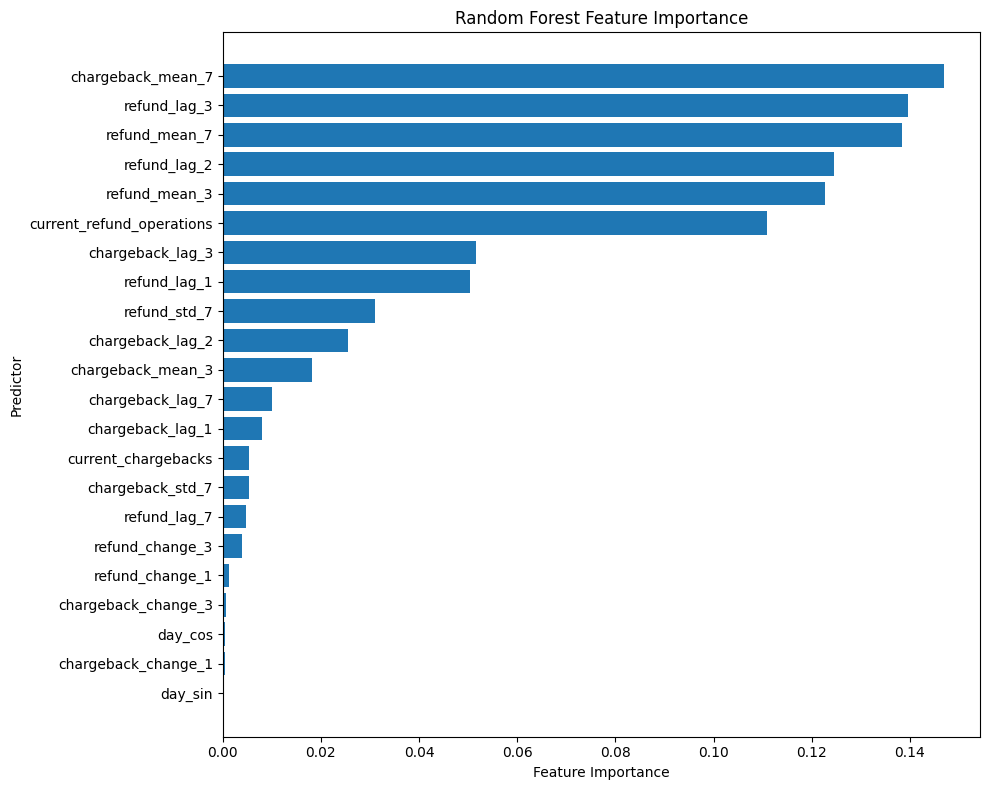

In [82]:
plt.figure(
    figsize=(10, 8)
)

plt.barh(
    feature_importance[
        "Feature"
    ][::-1],

    feature_importance[
        "Importance"
    ][::-1]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Predictor"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "/content/"
    "Random_Forest_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 7O — Ridge coefficients**

In [83]:
# ============================================================
# STEP 7O: RIDGE COEFFICIENTS
# ============================================================

ridge_coefficients = pd.DataFrame({

    "Feature":
        features,

    "Coefficient":
        ridge_model[
            "ridge"
        ].coef_
})


ridge_coefficients[
    "Absolute_Coefficient"
] = (
    ridge_coefficients[
        "Coefficient"
    ]
    .abs()
)


ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "RIDGE REGRESSION COEFFICIENTS"
)

display(
    ridge_coefficients
)

RIDGE REGRESSION COEFFICIENTS


,Feature,Coefficient,Absolute_Coefficient
0,refund_lag_1,90.374434,90.374434
1,current_refund_operations,87.489246,87.489246
2,refund_lag_3,87.463761,87.463761
3,refund_lag_2,-50.373720,50.373720
4,refund_mean_3,46.876851,46.876851
5,refund_change_3,45.700627,45.700627
6,refund_mean_7,25.860112,25.860112
7,refund_change_1,19.021492,19.021492
8,chargeback_mean_7,-17.828317,17.828317
9,chargeback_std_7,15.953420,15.953420


**Step 7P — Save the best model**

In [84]:
# ============================================================
# STEP 7P: SAVE SELECTED MODEL
# ============================================================

if (
    best_model_name
    ==
    "Ridge Regression"
):

    best_model = ridge_model

    model_filename = (
        "/content/"
        "Selected_RCSA_Ridge_Model.pkl"
    )

else:

    best_model = rf_model

    model_filename = (
        "/content/"
        "Selected_RCSA_Random_Forest_Model.pkl"
    )


joblib.dump(
    best_model,
    model_filename
)


print(
    "Saved selected model:"
)

print(
    model_filename
)

Saved selected model:
/content/Selected_RCSA_Ridge_Model.pkl


**Step 7R — Predict the next future day**

In [87]:
# ============================================================
# STEP 7R RECOVERY:
# LOAD OR REBUILD final_model
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


MODEL_PATH = "/content/Final_Multi_KRI_Predictive_Model.pkl"


# ------------------------------------------------------------
# OPTION 1:
# Load model if it was already saved
# ------------------------------------------------------------

if os.path.exists(MODEL_PATH):

    final_model = joblib.load(
        MODEL_PATH
    )

    print("Saved final model loaded successfully.")


# ------------------------------------------------------------
# OPTION 2:
# Rebuild model if saved file is not available
# ------------------------------------------------------------

else:

    print(
        "Saved model not found. "
        "Rebuilding final model..."
    )

    # Check required variables
    required_variables = [
        "model_df",
        "features",
        "performance_table"
    ]

    missing_variables = [
        var
        for var in required_variables
        if var not in globals()
    ]

    if missing_variables:

        raise NameError(
            "Missing required variables: "
            + ", ".join(missing_variables)
            + ". Please rerun Step 7A through Step 7I first."
        )


    # ---------------------------------------
    # Identify best model again
    # ---------------------------------------

    ranked_models = (
        performance_table
        .sort_values(
            by=[
                "RMSE",
                "MAE",
                "MAPE (%)"
            ],
            ascending=[
                True,
                True,
                True
            ]
        )
        .reset_index(drop=True)
    )


    best_model_name = (
        ranked_models.loc[
            0,
            "Model"
        ]
    )


    print(
        "Selected model:",
        best_model_name
    )


    # ---------------------------------------
    # Full historical training dataset
    # ---------------------------------------

    X_all = model_df[
        features
    ]

    y_all = model_df[
        "next_day_refund_operations"
    ]


    # ---------------------------------------
    # Rebuild selected algorithm
    # ---------------------------------------

    if (
        best_model_name
        ==
        "Ridge Regression"
    ):

        final_model = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "ridge",
                Ridge(
                    alpha=1.0
                )
            )
        ])


    elif (
        best_model_name
        ==
        "Random Forest Regression"
    ):

        final_model = (
            RandomForestRegressor(
                n_estimators=500,
                max_depth=6,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )


    else:

        raise ValueError(
            "Model name not recognized: "
            + str(best_model_name)
        )


    # ---------------------------------------
    # Fit selected model
    # ---------------------------------------

    final_model.fit(
        X_all,
        y_all
    )


    # ---------------------------------------
    # Save it
    # ---------------------------------------

    joblib.dump(
        final_model,
        MODEL_PATH
    )

    print(
        "Final model rebuilt and saved."
    )


# ------------------------------------------------------------
# CONFIRM final_model EXISTS
# ------------------------------------------------------------

print("\nMODEL CHECK")
print("=" * 50)

print(
    "final_model type:",
    type(final_model)
)

print(
    "Model available:",
    "final_model" in globals()
)

Saved model not found. Rebuilding final model...
Selected model: Ridge Regression
Final model rebuilt and saved.

MODEL CHECK
final_model type: <class 'sklearn.pipeline.Pipeline'>
Model available: True


**Run the forecast**

In [88]:
# ============================================================
# STEP 7R:
# GENERATE NEXT-DAY FORECAST
# ============================================================

# Ensure feature-engineered dataframe exists
if "df" not in globals():

    raise NameError(
        "The feature-engineered dataframe 'df' "
        "is missing. Rerun Step 7C first."
    )


# Select rows where all required predictors exist
forecast_candidates = (
    df[
        ["date"] + features
    ]
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)


print(
    "Available forecasting rows:",
    len(forecast_candidates)
)


# Most recent observation
latest_row = (
    forecast_candidates
    .iloc[[-1]]
)


latest_features = (
    latest_row[
        features
    ]
)


latest_date = (
    latest_row[
        "date"
    ]
    .iloc[0]
)


# ------------------------------------------------------------
# GENERATE FORECAST
# ------------------------------------------------------------

next_day_prediction = (
    final_model
    .predict(
        latest_features
    )[0]
)


forecast_date = (
    latest_date
    +
    pd.Timedelta(
        days=1
    )
)


print("\n" + "=" * 65)

print(
    "NEXT-DAY REFUND OPERATIONS FORECAST"
)

print("=" * 65)

print(
    "Latest observation date:",
    latest_date.date()
)

print(
    "Forecast date:",
    forecast_date.date()
)

print(
    "Predicted refund operations:",
    round(
        float(next_day_prediction),
        2
    )
)

if "best_model_name" in globals():

    print(
        "Selected predictive model:",
        best_model_name
    )

Available forecasting rows: 141

NEXT-DAY REFUND OPERATIONS FORECAST
Latest observation date: 2026-08-26
Forecast date: 2026-08-27
Predicted refund operations: 471.9
Selected predictive model: Ridge Regression


In [89]:
final_model

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

**Step 8A — Load the deterministic composite model output**

In [90]:
# ============================================================
# STEP 8A: LOAD DETERMINISTIC MULTI-KRI OUTPUT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

composite_data = pd.read_csv(
    "/content/Multi_KRI_Composite_Model_Output.csv"
)

composite_data["date"] = pd.to_datetime(
    composite_data["date"],
    errors="coerce"
)

composite_data = (
    composite_data
    .sort_values("date")
    .reset_index(drop=True)
)

print(
    "Composite observations:",
    len(composite_data)
)

display(
    composite_data.tail()
)

Composite observations: 11


,date,KRI1,KRI2,KRI3_waiting_refunds_after_14_days,KRI4_chargebacks,KRI5_historical_refund_operations,Available_KRI_Count,KRI3_Class,KRI4_Class,KRI3_Score,KRI4_Score,KRI3_Weighted,KRI4_Weighted,Composite_Risk_Score,Composite_Class,RCSA_Decision_Support
6,2026-08-22,642.0,688497.0,46.0,203.0,454,5,Red,Amber,3.0,2.0,1.5,1.0,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
7,2026-08-23,638.0,688515.0,42.0,205.0,454,5,Amber,Amber,2.0,2.0,1.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
8,2026-08-24,687.0,688516.0,43.0,207.0,454,5,Amber,Amber,2.0,2.0,1.0,1.0,2.0,Amber,"Enhanced monitoring; review trends, controls, ..."
9,2026-08-25,692.0,688580.0,48.0,208.0,454,5,Red,Amber,3.0,2.0,1.5,1.0,2.5,Red,"RCSA review/escalation; investigate drivers, a..."
10,2026-08-26,600.0,688717.0,33.0,209.0,451,5,Green,Amber,1.0,2.0,0.5,1.0,1.5,Amber,"Enhanced monitoring; review trends, controls, ..."


**Step 8B — Extract the most recent deterministic RCSA evidence**

In [91]:
# ============================================================
# STEP 8B: LATEST DETERMINISTIC RCSA RESULT
# ============================================================

latest_composite = (
    composite_data
    .dropna(
        subset=[
            "Composite_Risk_Score",
            "Composite_Class"
        ]
    )
    .iloc[-1]
)

latest_composite_date = (
    latest_composite["date"]
)

latest_composite_score = float(
    latest_composite[
        "Composite_Risk_Score"
    ]
)

latest_composite_class = (
    latest_composite[
        "Composite_Class"
    ]
)

print("=" * 60)

print(
    "LATEST DETERMINISTIC RCSA EVIDENCE"
)

print("=" * 60)

print(
    "Observation date:",
    latest_composite_date.date()
)

print(
    "Composite risk score:",
    latest_composite_score
)

print(
    "Composite classification:",
    latest_composite_class
)

LATEST DETERMINISTIC RCSA EVIDENCE
Observation date: 2026-08-26
Composite risk score: 1.5
Composite classification: Amber


**Step 8C — Confirm the predictive forecast**

In [92]:
# ============================================================
# STEP 8C: CHECK PREDICTIVE OUTPUT
# ============================================================

print("=" * 60)

print(
    "PREDICTIVE EARLY-WARNING COMPONENT"
)

print("=" * 60)

print(
    "Selected model:",
    best_model_name
)

print(
    "Forecast date:",
    forecast_date.date()
)

print(
    "Predicted refund operations:",
    round(
        float(next_day_prediction),
        2
    )
)

PREDICTIVE EARLY-WARNING COMPONENT
Selected model: Ridge Regression
Forecast date: 2026-08-27
Predicted refund operations: 471.9


**Step 8D — Compare the forecast with recent operating levels**

In [93]:
# ============================================================
# STEP 8D: PREDICTIVE CONTEXT ANALYSIS
# ============================================================

recent_refunds = (
    daily_data[
        [
            "date",
            "KRI5_historical_refund_operations"
        ]
    ]
    .dropna()
    .sort_values("date")
    .tail(7)
    .copy()
)

recent_mean = (
    recent_refunds[
        "KRI5_historical_refund_operations"
    ]
    .mean()
)

recent_std = (
    recent_refunds[
        "KRI5_historical_refund_operations"
    ]
    .std()
)

latest_actual_refunds = (
    recent_refunds[
        "KRI5_historical_refund_operations"
    ]
    .iloc[-1]
)


forecast_difference = (
    next_day_prediction
    -
    recent_mean
)


if recent_mean != 0:

    forecast_change_percent = (
        forecast_difference
        /
        recent_mean
        * 100
    )

else:

    forecast_change_percent = np.nan


if (
    recent_std is not None
    and
    not np.isnan(recent_std)
    and
    recent_std > 0
):

    forecast_z_score = (
        next_day_prediction
        -
        recent_mean
    ) / recent_std

else:

    forecast_z_score = np.nan


print(
    "Recent 7-day mean:",
    round(
        recent_mean,
        2
    )
)

print(
    "Recent 7-day standard deviation:",
    round(
        recent_std,
        2
    )
)

print(
    "Predicted next-day value:",
    round(
        next_day_prediction,
        2
    )
)

print(
    "Difference from recent mean:",
    round(
        forecast_difference,
        2
    )
)

print(
    "Percentage difference:",
    round(
        forecast_change_percent,
        2
    ),
    "%"
)

print(
    "Forecast Z-score:",
    round(
        forecast_z_score,
        3
    )
)

Recent 7-day mean: 453.57
Recent 7-day standard deviation: 1.13
Predicted next-day value: 471.9
Difference from recent mean: 18.33
Percentage difference: 4.04 %
Forecast Z-score: 16.165


**Step 8E — Convert forecast deviation into an operational monitoring signal**

We are not calling these Green/Amber/Red risk classifications.

Instead:

Within Recent Range
Above Recent Range
Substantially Above Recent Range
Below Recent Range

In [94]:
# ============================================================
# STEP 8E: PREDICTIVE MONITORING SIGNAL
# ============================================================

def predictive_monitoring_signal(z):

    if pd.isna(z):
        return "Insufficient variability information"

    elif z >= 2:
        return "Substantially Above Recent Range"

    elif z >= 1:
        return "Above Recent Range"

    elif z <= -2:
        return "Substantially Below Recent Range"

    elif z <= -1:
        return "Below Recent Range"

    else:
        return "Within Recent Range"


forecast_signal = (
    predictive_monitoring_signal(
        forecast_z_score
    )
)


print(
    "Predictive monitoring signal:",
    forecast_signal
)

Predictive monitoring signal: Substantially Above Recent Range


**Step 8F — Build integrated decision-support logic**

In [97]:
# ============================================================
# STEP 8F: INTEGRATED RCSA DECISION-SUPPORT LOGIC
# ============================================================

def integrated_rcsa_signal(
    composite_class,
    predictive_signal
):

    # ---------------------------------------
    # RED deterministic evidence
    # ---------------------------------------

    if composite_class == "Red":

        if predictive_signal in [
            "Above Recent Range",
            "Substantially Above Recent Range"
        ]:

            return (
                "Priority RCSA review supported. "
                "Current multi-KRI evidence is Red "
                "and the predictive component indicates "
                "higher-than-recent refund operational activity. "
                "Investigate the underlying drivers, "
                "review control effectiveness, and determine "
                "whether the current RCSA assessment remains appropriate."
            )

        else:

            return (
                "RCSA review or escalation supported by "
                "current Red multi-KRI evidence. "
                "Investigate the risk drivers and review "
                "control effectiveness."
            )


    # ---------------------------------------
    # AMBER deterministic evidence
    # ---------------------------------------

    elif composite_class == "Amber":

        if predictive_signal in [
            "Above Recent Range",
            "Substantially Above Recent Range"
        ]:

            return (
                "Enhanced monitoring and RCSA review supported. "
                "Current multi-KRI evidence is Amber and "
                "the forecast indicates increasing operational activity. "
                "Review refund-processing conditions, backlog indicators, "
                "chargebacks, and relevant controls."
            )

        else:

            return (
                "Enhanced monitoring supported. "
                "Current multi-KRI evidence is Amber. "
                "Continue trend monitoring and assess whether "
                "the existing RCSA rating remains appropriate."
            )


    # ---------------------------------------
    # GREEN deterministic evidence
    # ---------------------------------------

    elif composite_class == "Green":

        if predictive_signal in [
            "Above Recent Range",
            "Substantially Above Recent Range"
        ]:

            return (
                "Current multi-KRI evidence remains Green, "
                "but the predictive component indicates "
                "higher-than-recent refund operational activity. "
                "Maintain the current RCSA assessment while "
                "increasing short-term monitoring."
            )

        else:

            return (
                "Routine monitoring supported. "
                "Current multi-KRI evidence is Green and "
                "the predictive component does not indicate "
                "an unusual increase in refund operational activity."
            )

    else:

        return (
            "Insufficient evidence for integrated RCSA decision support."
        )


integrated_signal = (
    integrated_rcsa_signal(
        latest_composite_class,
        forecast_signal
    )
)


print("=" * 70)

print(
    "INTEGRATED RCSA DECISION-SUPPORT SIGNAL"
)

print("=" * 70)

print(
    integrated_signal
)

INTEGRATED RCSA DECISION-SUPPORT SIGNAL
Enhanced monitoring and RCSA review supported. Current multi-KRI evidence is Amber and the forecast indicates increasing operational activity. Review refund-processing conditions, backlog indicators, chargebacks, and relevant controls.


**Step 8G — Build the final integrated output record**

In [ ]:
# ============================================================
# STEP 8G: FINAL INTEGRATED MODEL OUTPUT
# ============================================================

integrated_output = pd.DataFrame([{

    "Latest_RCSA_Evidence_Date":
        latest_composite_date,

    "KRI3_Waiting_Refunds_Class":
        latest_composite[
            "KRI3_Class"
        ],

    "KRI4_Chargeback_Class":
        latest_composite[
            "KRI4_Class"
        ],

    "Composite_Risk_Score":
        latest_composite_score,

    "Composite_Risk_Class":
        latest_composite_class,

    "Selected_Predictive_Model":
        best_model_name,

    "Forecast_Date":
        forecast_date,

    "Predicted_Refund_Operations":
        round(
            float(
                next_day_prediction
            ),
            2
        ),

    "Recent_7_Day_Refund_Mean":
        round(
            recent_mean,
            2
        ),

    "Forecast_Deviation_Percent":
        round(
            forecast_change_percent,
            2
        ),

    "Forecast_Z_Score":
        round(
            forecast_z_score,
            3
        ),

    "Predictive_Monitoring_Signal":
        forecast_signal,

    "Integrated_RCSA_Signal":
        integrated_signal
}])


display(
    integrated_output.T
)

Step 8H — Add an evidence-trail ID

In [98]:
# ============================================================
# STEP 8H: AUDIT / EVIDENCE IDENTIFIER
# ============================================================

import hashlib


evidence_string = (
    str(latest_composite_date)
    +
    str(latest_composite_score)
    +
    str(latest_composite_class)
    +
    str(forecast_date)
    +
    str(round(
        next_day_prediction,
        4
    ))
)


evidence_id = hashlib.sha256(
    evidence_string.encode()
).hexdigest()[:16]


integrated_output[
    "Evidence_ID"
] = evidence_id


print(
    "Evidence ID:",
    evidence_id
)

NameError: name 'integrated_output' is not defined

**Step 8I — Create the complete evidence trail**

In [99]:
# ============================================================
# STEP 8I: COMPLETE INTEGRATED EVIDENCE TRAIL
# ============================================================

final_evidence_trail = pd.DataFrame([{

    "Evidence_ID":
        evidence_id,

    "Observed_Date":
        latest_composite_date,

    "Waiting_Refunds_Value":
        latest_composite[
            "KRI3_waiting_refunds_after_14_days"
        ],

    "Waiting_Refunds_Class":
        latest_composite[
            "KRI3_Class"
        ],

    "Waiting_Refunds_Score":
        latest_composite[
            "KRI3_Score"
        ],

    "Chargebacks_Value":
        latest_composite[
            "KRI4_chargebacks"
        ],

    "Chargebacks_Class":
        latest_composite[
            "KRI4_Class"
        ],

    "Chargebacks_Score":
        latest_composite[
            "KRI4_Score"
        ],

    "Composite_Score":
        latest_composite_score,

    "Composite_Class":
        latest_composite_class,

    "Predictive_Model":
        best_model_name,

    "Forecast_Date":
        forecast_date,

    "Predicted_Refund_Operations":
        round(
            next_day_prediction,
            2
        ),

    "Predictive_Context":
        forecast_signal,

    "RCSA_Decision_Support":
        integrated_signal
}])


print(
    "FINAL INTEGRATED RCSA EVIDENCE TRAIL"
)

display(
    final_evidence_trail.T
)

FINAL INTEGRATED RCSA EVIDENCE TRAIL


,0
Evidence_ID,bafa7e2215a2df14
Observed_Date,2026-08-26 00:00:00
Waiting_Refunds_Value,33.0
Waiting_Refunds_Class,Green
Waiting_Refunds_Score,1.0
Chargebacks_Value,209.0
Chargebacks_Class,Amber
Chargebacks_Score,2.0
Composite_Score,1.5
Composite_Class,Amber


**Step 8J — Create an integrated dashboard-style figure**

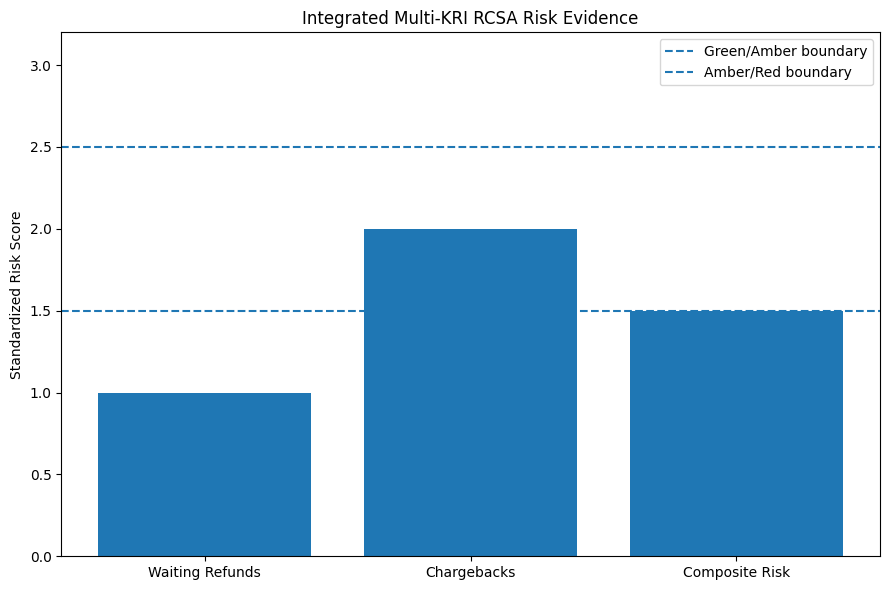

In [100]:
# ============================================================
# STEP 8J: INTEGRATED MODEL FIGURE
# ============================================================

figure_data = pd.DataFrame({

    "Component": [
        "Waiting Refunds",
        "Chargebacks",
        "Composite Risk"
    ],

    "Score": [
        latest_composite[
            "KRI3_Score"
        ],

        latest_composite[
            "KRI4_Score"
        ],

        latest_composite_score
    ]
})


plt.figure(
    figsize=(9, 6)
)

plt.bar(
    figure_data[
        "Component"
    ],
    figure_data[
        "Score"
    ]
)

plt.axhline(
    1.5,
    linestyle="--",
    label="Green/Amber boundary"
)

plt.axhline(
    2.5,
    linestyle="--",
    label="Amber/Red boundary"
)

plt.ylim(
    0,
    3.2
)

plt.ylabel(
    "Standardized Risk Score"
)

plt.title(
    "Integrated Multi-KRI RCSA Risk Evidence"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/"
    "Integrated_Multi_KRI_RCSA_Evidence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()